# SFT Telemetry Decision Notebook

Этот notebook нужен не для красивого отчёта, а для решения:

1. какие `label` усиливать в dense dataset;
2. какие `source + label` усиливать или резать;
3. где модель ошибается: `cot`, `format`, `final_answer`, `boxed_answer`;
4. какие параметры поставить в `dense.label_weights` и multipliers.

## Главная логика

- **Train telemetry** показывает, что модель тяжело воспроизводит во время обучения.
- **Eval telemetry** показывает, что плохо обобщается на unseen validation.
- **Bad tokens** показывают, проблема в задаче, в CoT, в формате или в самом boxed answer.
- **Dense dataset** лучше строить не по одному loss, а по пересечению `eval hard + answer hard + train hard`, с ручными весами.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 220)
pd.set_option("display.max_colwidth", 260)
pd.set_option("display.width", 260)


## 1. Paths

Если notebook лежит в папке `notebooks/`, оставь `PROJECT_ROOT = Path("..")`.

Если запускаешь из корня проекта, поставь:

```python
PROJECT_ROOT = Path(".")
```


In [2]:
PROJECT_ROOT = Path("..")

MODEL_DIR = PROJECT_ROOT / "models/sft_v0.0.13"

TRAIN_CSV = PROJECT_ROOT / "data/generated/train_with_syntetic.csv"
VAL_CSV = PROJECT_ROOT / "data/prepared/val_stratified.csv"

TRAIN_ANALYSIS_DIR = Path(str(MODEL_DIR) + "_train_telemetry_analysis")
EVAL_ANALYSIS_DIR = Path(str(MODEL_DIR) + "_eval_telemetry_analysis")

# fallback для старого single analysis dir
if not TRAIN_ANALYSIS_DIR.exists():
    fallback = Path(str(MODEL_DIR) + "_telemetry_analysis")
    if fallback.exists():
        TRAIN_ANALYSIS_DIR = fallback

TRAIN_TELEMETRY_DIR = MODEL_DIR / "train_telemetry"
EVAL_TELEMETRY_DIR = MODEL_DIR / "eval_telemetry"

print("MODEL_DIR:", MODEL_DIR, "exists=", MODEL_DIR.exists())
print("TRAIN_ANALYSIS_DIR:", TRAIN_ANALYSIS_DIR, "exists=", TRAIN_ANALYSIS_DIR.exists())
print("EVAL_ANALYSIS_DIR:", EVAL_ANALYSIS_DIR, "exists=", EVAL_ANALYSIS_DIR.exists())
print("TRAIN_TELEMETRY_DIR:", TRAIN_TELEMETRY_DIR, "exists=", TRAIN_TELEMETRY_DIR.exists())
print("EVAL_TELEMETRY_DIR:", EVAL_TELEMETRY_DIR, "exists=", EVAL_TELEMETRY_DIR.exists())
print("TRAIN_CSV:", TRAIN_CSV, "exists=", TRAIN_CSV.exists())
print("VAL_CSV:", VAL_CSV, "exists=", VAL_CSV.exists())


MODEL_DIR: ../models/sft_v0.0.13 exists= True
TRAIN_ANALYSIS_DIR: ../models/sft_v0.0.13_train_telemetry_analysis exists= True
EVAL_ANALYSIS_DIR: ../models/sft_v0.0.13_eval_telemetry_analysis exists= True
TRAIN_TELEMETRY_DIR: ../models/sft_v0.0.13/train_telemetry exists= True
EVAL_TELEMETRY_DIR: ../models/sft_v0.0.13/eval_telemetry exists= True
TRAIN_CSV: ../data/generated/train_with_syntetic.csv exists= True
VAL_CSV: ../data/prepared/val_stratified.csv exists= True


## 2. Load reports

In [3]:
def read_csv_if_exists(path: Path) -> pd.DataFrame:
    if path.exists():
        return pd.read_csv(path)
    print("Missing:", path)
    return pd.DataFrame()

def read_json_if_exists(path: Path) -> dict:
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    print("Missing:", path)
    return {}

def load_analysis(analysis_dir: Path) -> dict:
    return {
        "summary": read_json_if_exists(analysis_dir / "00_input_summary.json"),
        "by_label": read_csv_if_exists(analysis_dir / "01_by_label.csv"),
        "by_source_label": read_csv_if_exists(analysis_dir / "02_by_source_label.csv"),
        "hard_examples": read_csv_if_exists(analysis_dir / "03_hard_examples.csv"),
        "bad_tokens": read_csv_if_exists(analysis_dir / "04_bad_tokens.csv"),
    }

train = load_analysis(TRAIN_ANALYSIS_DIR)
eval_ = load_analysis(EVAL_ANALYSIS_DIR)

train_df = pd.read_csv(TRAIN_CSV) if TRAIN_CSV.exists() else pd.DataFrame()
val_df = pd.read_csv(VAL_CSV) if VAL_CSV.exists() else pd.DataFrame()

print("train by_label rows:", len(train["by_label"]))
print("eval by_label rows:", len(eval_["by_label"]))
print("train rows:", len(train_df))
print("val rows:", len(val_df))


train by_label rows: 8
eval by_label rows: 8
train rows: 11050
val rows: 950


## 3. Metric thresholds

Эти границы не абсолютная истина, но они дают нормальную шкалу.

### `mean_nll`
Средняя ошибка по target tokens.

| Значение | Интерпретация |
|---:|---|
| `< 0.02` | почти выучено |
| `0.02–0.08` | нормальная/средняя сложность |
| `0.08–0.18` | hard |
| `> 0.18` | very hard |

### `hard_token_ratio`
Доля токенов с `logprob < -1.0`, то есть модель дала target token probability меньше `e^-1 ≈ 36.8%`.

| Значение | Интерпретация |
|---:|---|
| `< 0.01` | почти нет плохих токенов |
| `0.01–0.02` | немного плохих токенов |
| `0.02–0.08` | hard |
| `> 0.08` | very hard |

### `near_zero_token_ratio`
Доля токенов с `logprob > -0.05`, то есть probability target token примерно больше `95%`.

| Значение | Интерпретация |
|---:|---|
| `> 0.97` | почти заучено |
| `0.90–0.97` | нормально |
| `< 0.90` | много неуверенных токенов |

### `boxed_answer_mean_nll`
Ошибка именно по ответу внутри `\boxed{...}`.

| Значение | Интерпретация |
|---:|---|
| `< 0.02` | answer почти выучен |
| `0.02–0.08` | medium |
| `0.08–0.15` | answer hard |
| `> 0.15` | answer very hard |

### Что реально важно для dense
- `eval_boxed_answer_mean_nll` высокий → усиливать.
- `eval_difficulty_score` высокий → плохо обобщается, усиливать label/source.
- `train hard`, но `eval easy` → возможно формат/CoT, не дублировать вслепую.
- `format_mean_nll` высокий или bad tokens в `format` → чинить шаблон/CoT, не только дублировать.


In [4]:
def level_mean_nll(x):
    if pd.isna(x): return "unknown"
    if x < 0.02: return "easy"
    if x < 0.08: return "medium"
    if x < 0.18: return "hard"
    return "very_hard"

def level_hard_ratio(x):
    if pd.isna(x): return "unknown"
    if x < 0.01: return "easy"
    if x < 0.02: return "medium"
    if x < 0.08: return "hard"
    return "very_hard"

def level_near_zero(x):
    if pd.isna(x): return "unknown"
    if x > 0.97: return "almost_memorized"
    if x > 0.90: return "normal"
    return "not_learned"

def level_boxed_nll(x):
    if pd.isna(x): return "unknown"
    if x < 0.02: return "answer_easy"
    if x < 0.08: return "answer_medium"
    if x < 0.15: return "answer_hard"
    return "answer_very_hard"


## 4. Sanity check

In [5]:
print("TRAIN SUMMARY")
display(pd.DataFrame([train["summary"]]))

print("EVAL SUMMARY")
display(pd.DataFrame([eval_["summary"]]))

def sanity_notes(summary, name):
    if not summary:
        print(name, "summary missing")
        return

    print(f"\n{name} notes:")
    print("telemetry files:", summary.get("telemetry_files_count"))
    print("raw records:", summary.get("raw_records_count"))
    print("unique ids:", summary.get("unique_ids_raw"))
    print("unknown source:", summary.get("unknown_source_count"))
    print("unknown label:", summary.get("unknown_label_count"))
    print("zero loss tokens:", summary.get("zero_loss_tokens_count"))
    print("checkpoint buckets:", summary.get("checkpoint_buckets"))

sanity_notes(train["summary"], "TRAIN")
sanity_notes(eval_["summary"], "EVAL")


TRAIN SUMMARY


,telemetry_files_count,telemetry_files,raw_records_count,latest_records_count,unique_ids_raw,unique_ids_latest,unknown_source_count,unknown_label_count,zero_loss_tokens_count,checkpoint_buckets
0,7,"[models/sft_v0.0.13/train_telemetry/train_until_checkpoint-100_rank-0.jsonl, models/sft_v0.0.13/train_telemetry/train_until_checkpoint-150_rank-0.jsonl, models/sft_v0.0.13/train_telemetry/train_until_checkpoint-200_rank-0.jsonl, models/sft_v0.0.13/train_te...",11050,11050,11050,11050,0,0,0,"[50, 100, 150, 200, 250, 300, 350]"


EVAL SUMMARY


,telemetry_files_count,telemetry_files,raw_records_count,latest_records_count,unique_ids_raw,unique_ids_latest,unknown_source_count,unknown_label_count,zero_loss_tokens_count,checkpoint_buckets
0,6,"[models/sft_v0.0.13/eval_telemetry/eval_at_checkpoint-100_rank-0.jsonl, models/sft_v0.0.13/eval_telemetry/eval_at_checkpoint-150_rank-0.jsonl, models/sft_v0.0.13/eval_telemetry/eval_at_checkpoint-200_rank-0.jsonl, models/sft_v0.0.13/eval_telemetry/eval_at_...",5118,5118,853,853,0,0,0,"[50, 100, 150, 200, 250, 300]"



TRAIN notes:
telemetry files: 7
raw records: 11050
unique ids: 11050
unknown source: 0
unknown label: 0
zero loss tokens: 0
checkpoint buckets: [50, 100, 150, 200, 250, 300, 350]

EVAL notes:
telemetry files: 6
raw records: 5118
unique ids: 853
unknown source: 0
unknown label: 0
zero loss tokens: 0
checkpoint buckets: [50, 100, 150, 200, 250, 300]


Если `unknown_source_count`, `unknown_label_count` или `zero_loss_tokens_count` не равны нулю — сначала чинить telemetry, потом делать выводы.


## 5. Train vs Eval by label

In [6]:
def prepare_by_label(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()

    keep = [
        "label", "count", "unique_ids", "difficulty_score",
        "mean_nll", "p50_mean_nll", "p95_mean_nll",
        "hard_token_ratio", "near_zero_token_ratio",
        "cot_mean_nll", "final_answer_mean_nll", "boxed_answer_mean_nll", "format_mean_nll",
        "answer_score", "cot_score", "format_score",
        "hard_examples_ratio", "very_hard_examples_ratio", "easy_examples_ratio",
    ]
    keep = [c for c in keep if c in df.columns]

    out = df[keep].copy()
    out = out.rename(columns={c: f"{prefix}_{c}" for c in out.columns if c != "label"})
    return out

train_label = prepare_by_label(train["by_label"], "train")
eval_label = prepare_by_label(eval_["by_label"], "eval")

if not train_label.empty and not eval_label.empty:
    label_cmp = train_label.merge(eval_label, on="label", how="outer")
elif not train_label.empty:
    label_cmp = train_label.copy()
else:
    label_cmp = eval_label.copy()

if not label_cmp.empty:
    label_cmp["decision_score"] = (
        label_cmp.get("eval_difficulty_score", 0).fillna(0) * 2.0
        + label_cmp.get("eval_hard_examples_ratio", 0).fillna(0) * 1.5
        + label_cmp.get("eval_boxed_answer_mean_nll", 0).fillna(0) * 2.0
        + label_cmp.get("train_difficulty_score", 0).fillna(0) * 1.0
    )

    for prefix in ["train", "eval"]:
        if f"{prefix}_mean_nll" in label_cmp.columns:
            label_cmp[f"{prefix}_mean_nll_level"] = label_cmp[f"{prefix}_mean_nll"].apply(level_mean_nll)
        if f"{prefix}_hard_token_ratio" in label_cmp.columns:
            label_cmp[f"{prefix}_hard_token_ratio_level"] = label_cmp[f"{prefix}_hard_token_ratio"].apply(level_hard_ratio)
        if f"{prefix}_near_zero_token_ratio" in label_cmp.columns:
            label_cmp[f"{prefix}_near_zero_level"] = label_cmp[f"{prefix}_near_zero_token_ratio"].apply(level_near_zero)
        if f"{prefix}_boxed_answer_mean_nll" in label_cmp.columns:
            label_cmp[f"{prefix}_boxed_answer_level"] = label_cmp[f"{prefix}_boxed_answer_mean_nll"].apply(level_boxed_nll)

    label_cmp = label_cmp.sort_values("decision_score", ascending=False)

display(label_cmp)


,label,train_count,train_unique_ids,train_difficulty_score,train_mean_nll,train_p50_mean_nll,train_p95_mean_nll,train_hard_token_ratio,train_near_zero_token_ratio,train_cot_mean_nll,train_final_answer_mean_nll,train_boxed_answer_mean_nll,train_format_mean_nll,train_answer_score,train_cot_score,train_format_score,train_hard_examples_ratio,train_very_hard_examples_ratio,train_easy_examples_ratio,eval_count,eval_unique_ids,eval_difficulty_score,eval_mean_nll,eval_p50_mean_nll,eval_p95_mean_nll,eval_hard_token_ratio,eval_near_zero_token_ratio,eval_cot_mean_nll,eval_final_answer_mean_nll,eval_boxed_answer_mean_nll,eval_format_mean_nll,eval_answer_score,eval_cot_score,eval_format_score,eval_hard_examples_ratio,eval_very_hard_examples_ratio,eval_easy_examples_ratio,decision_score,train_mean_nll_level,train_hard_token_ratio_level,train_near_zero_level,train_boxed_answer_level,eval_mean_nll_level,eval_hard_token_ratio_level,eval_near_zero_level,eval_boxed_answer_level
7,unit conversion,1435,1435,0.590360,0.217368,0.152597,0.748433,0.076751,0.842328,NaN,0.044070,0.000059,0.228962,0.000059,0.0,0.310203,1.000000,0.683624,0.000000,954,159,0.459414,0.150724,0.144957,0.220908,0.059369,0.869333,NaN,0.000016,6.691736e-07,0.159920,6.691736e-07,0.0,0.222915,1.000000,0.627883,0.000000,3.009189,very_hard,hard,not_learned,answer_easy,hard,hard,not_learned,answer_easy
2,cryptarithm,1408,1408,0.253718,0.111382,0.048192,0.640275,0.032757,0.916059,NaN,0.076361,0.270984,0.111447,0.328861,0.0,0.144287,0.571733,0.322443,0.000000,186,31,0.111906,0.049148,0.042761,0.095461,0.017630,0.946911,NaN,0.034878,2.718663e-01,0.048819,3.390706e-01,0.0,0.066445,0.408602,0.182796,0.000000,1.634166,hard,hard,normal,answer_very_hard,medium,medium,normal,answer_very_hard
6,string,65,65,0.358484,0.202349,0.040104,1.261915,0.051140,0.891021,NaN,0.046105,0.000032,0.216433,0.000032,0.0,0.271378,0.353846,0.153846,0.200000,42,7,0.040327,0.039359,0.027913,0.070838,0.010847,0.964086,NaN,0.000012,4.846421e-07,0.042584,4.846421e-07,0.0,0.054319,0.142857,0.023810,0.261905,0.653426,very_hard,hard,not_learned,answer_easy,medium,medium,normal,answer_easy
5,numeral equations,1419,1419,0.111378,0.055937,0.008923,0.386644,0.013498,0.965101,NaN,0.036988,0.002044,0.056437,0.002217,0.0,0.070092,0.083157,0.064130,0.821705,276,46,0.008771,0.010835,0.008285,0.022502,0.003768,0.986555,NaN,0.000005,8.853943e-03,0.011016,1.247713e-02,0.0,0.014846,0.025362,0.021739,0.894928,0.184671,medium,medium,normal,answer_easy,easy,easy,almost_memorized,answer_easy
1,conversion to diff numeral system,1418,1418,0.125466,0.066313,0.000021,0.582251,0.015528,0.966177,NaN,0.051957,0.001275,0.068150,0.001627,0.0,0.084513,0.074753,0.068406,0.908322,948,158,0.000441,0.000474,0.000019,0.000455,0.000101,0.999616,NaN,0.000033,8.082201e-04,0.000499,1.335646e-03,0.0,0.000601,0.001055,0.001055,0.989451,0.129546,medium,medium,normal,answer_easy,easy,easy,almost_memorized,answer_easy
4,gravitational,1437,1437,0.085737,0.056962,0.030472,0.268128,0.018904,0.962276,NaN,0.036023,0.000178,0.057803,0.000178,0.0,0.077089,0.068894,0.059151,0.008351,960,160,0.017466,0.030009,0.029614,0.037971,0.012039,0.977942,NaN,0.000012,5.150524e-07,0.030764,5.150524e-07,0.0,0.043106,0.000000,0.000000,0.007292,0.120671,medium,medium,normal,answer_easy,medium,medium,almost_memorized,answer_easy
3,encryption,2102,2102,0.095178,0.049463,0.009609,0.304988,0.012132,0.966208,NaN,0.024375,0.001634,0.050568,0.001634,0.0,0.063011,0.077069,0.058516,0.716936,948,158,0.007532,0.012569,0.008884,0.034808,0.003365,0.986084,NaN,0.000016,5.042446e-05,0.013043,5.042446e-05,0.0,0.016535,0.001055,0.000000,0.770042,0.111924,medium,medium,normal,answer_easy,easy,easy,almost_memorized,answer_easy
0,bit manipulation,1766,1766,0.078860,0.041707,0.009897,0.304374,0.010795,0.969437,NaN,0.039397,0.000009,0.042211,0.000009,0.0,0.053184,0.086070,0.067384,0.757644,804,134,0.006732,0.011342,0.008791,0.026969,0.004097,0.988206,NaN,0.000010,2.238509e-07,0.011583,2.238509e-07,0.0,0.

### Как читать таблицу label

Ищи не просто верхнюю строку, а паттерн:

| Паттерн | Решение |
|---|---|
| `eval hard` + `boxed_answer hard` | усиливать label |
| `train hard` + `eval easy` | проверить bad tokens; возможно CoT/format |
| `train easy` + `eval hard` | не хватает diversity, нужны новые примеры |
| `train easy` + `eval easy` | downsample |
| `format hard` | чинить формат/trace, а не дублировать вслепую |


## 6. Label visualizations

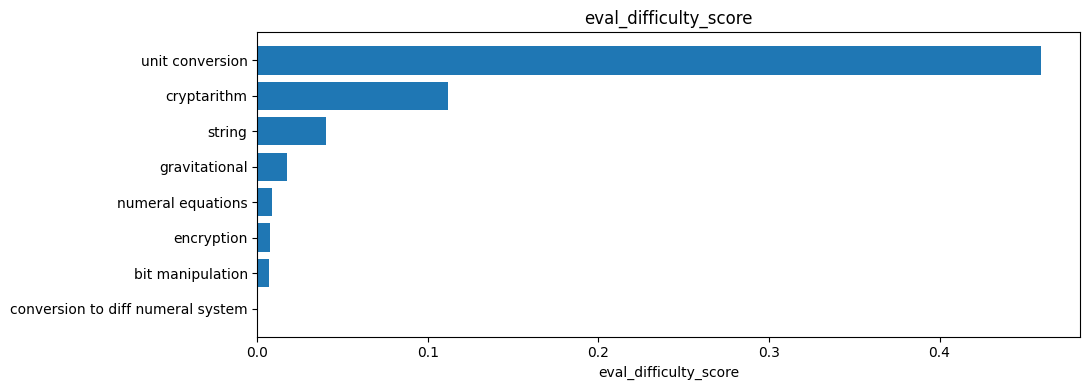

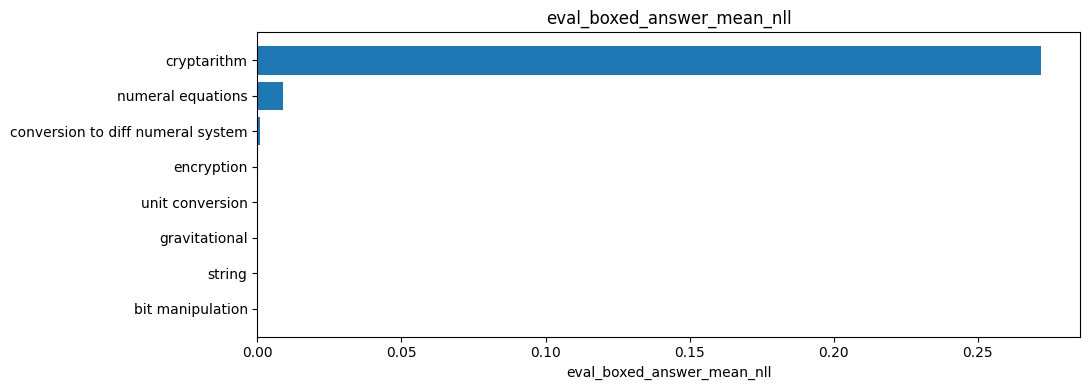

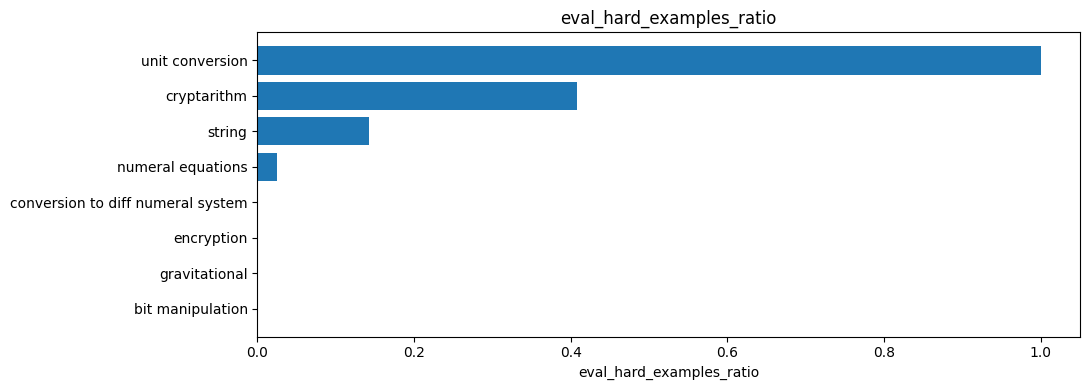

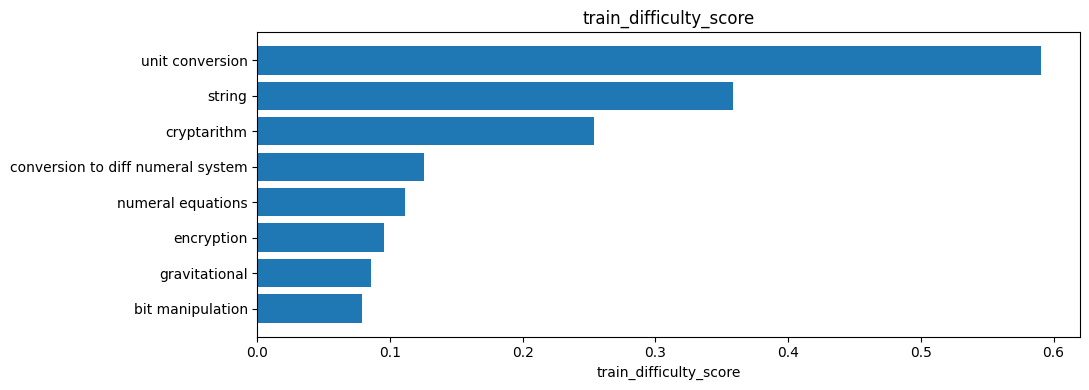

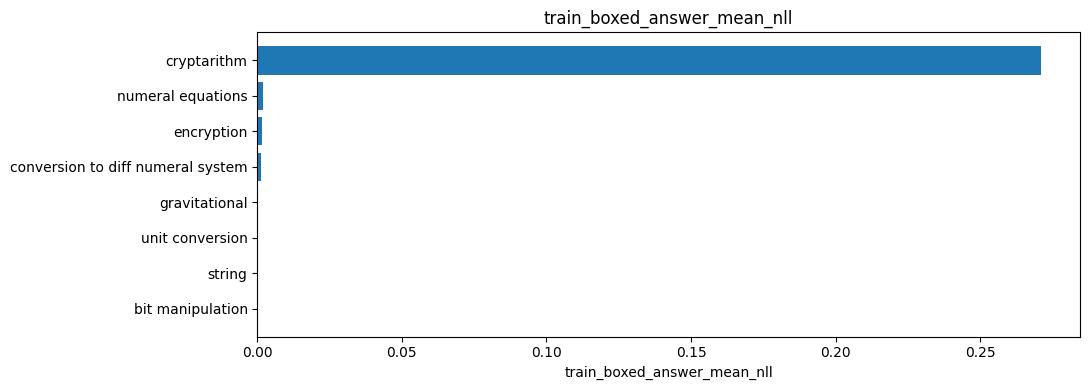

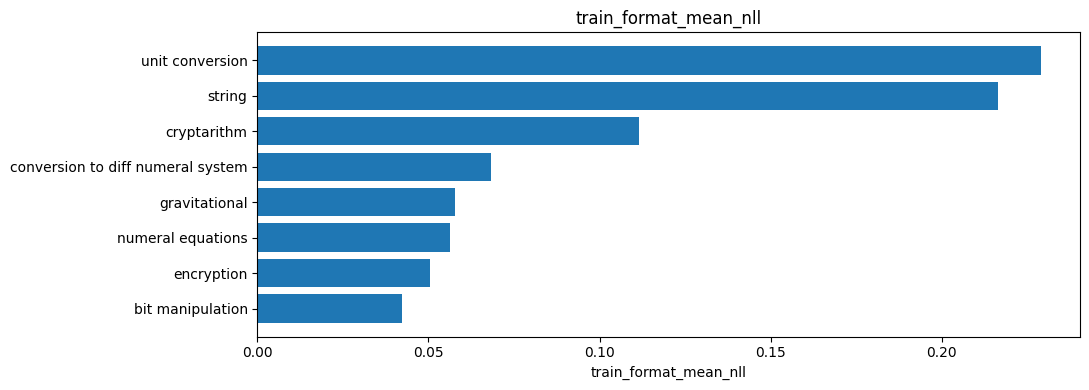

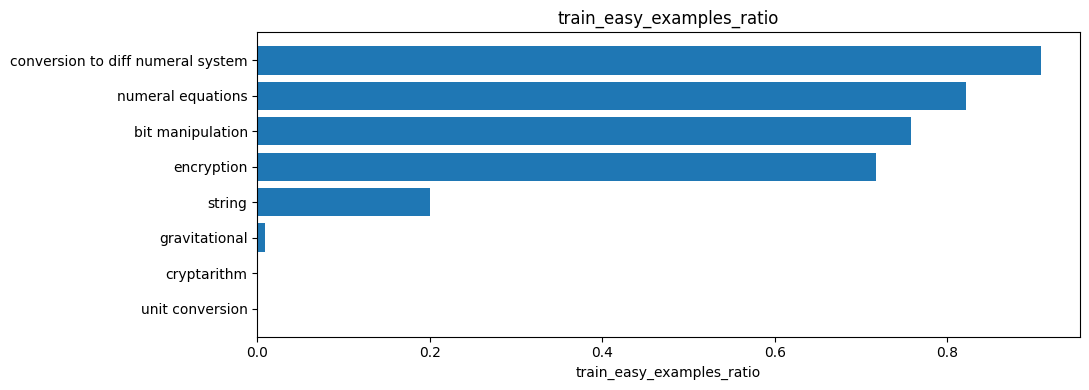

In [7]:
def plot_metric(df, metric, title=None, top_n=None):
    if df.empty or metric not in df.columns:
        print("Missing metric:", metric)
        return

    plot_df = df[["label", metric]].dropna().copy()
    plot_df = plot_df.sort_values(metric, ascending=True)

    if top_n is not None and len(plot_df) > top_n:
        plot_df = plot_df.tail(top_n)

    plt.figure(figsize=(11, max(4, len(plot_df) * 0.48)))
    plt.barh(plot_df["label"], plot_df[metric])
    plt.title(title or metric)
    plt.xlabel(metric)
    plt.tight_layout()
    plt.show()

for metric in [
    "eval_difficulty_score",
    "eval_boxed_answer_mean_nll",
    "eval_hard_examples_ratio",
    "train_difficulty_score",
    "train_boxed_answer_mean_nll",
    "train_format_mean_nll",
    "train_easy_examples_ratio",
]:
    if metric in label_cmp.columns:
        plot_metric(label_cmp, metric)


### Что считать высоким на графиках

- `difficulty_score > 0.10` — уже заметно hard.
- `difficulty_score > 0.20` — очень hard.
- `boxed_answer_mean_nll > 0.08` — ответ реально плохо учится.
- `hard_examples_ratio > 0.25` — много проблемных примеров.
- `easy_examples_ratio > 0.70` — можно заметно downsample.


## 7. Section diagnostics: CoT / Final / Boxed / Format

In [8]:
section_cols = [
    "train_cot_mean_nll",
    "train_final_answer_mean_nll",
    "train_boxed_answer_mean_nll",
    "train_format_mean_nll",
    "eval_cot_mean_nll",
    "eval_final_answer_mean_nll",
    "eval_boxed_answer_mean_nll",
    "eval_format_mean_nll",
]

available_section_cols = [c for c in section_cols if c in label_cmp.columns]

section_view_cols = ["label", "decision_score"] + available_section_cols
section_view = label_cmp[section_view_cols].copy() if not label_cmp.empty else pd.DataFrame()
display(section_view)


,label,decision_score,train_cot_mean_nll,train_final_answer_mean_nll,train_boxed_answer_mean_nll,train_format_mean_nll,eval_cot_mean_nll,eval_final_answer_mean_nll,eval_boxed_answer_mean_nll,eval_format_mean_nll
7,unit conversion,3.009189,NaN,0.044070,0.000059,0.228962,NaN,0.000016,6.691736e-07,0.159920
2,cryptarithm,1.634166,NaN,0.076361,0.270984,0.111447,NaN,0.034878,2.718663e-01,0.048819
6,string,0.653426,NaN,0.046105,0.000032,0.216433,NaN,0.000012,4.846421e-07,0.042584
5,numeral equations,0.184671,NaN,0.036988,0.002044,0.056437,NaN,0.000005,8.853943e-03,0.011016
1,conversion to diff numeral system,0.129546,NaN,0.051957,0.001275,0.068150,NaN,0.000033,8.082201e-04,0.000499
4,gravitational,0.120671,NaN,0.036023,0.000178,0.057803,NaN,0.000012,5.150524e-07,0.030764
3,encryption,0.111924,NaN,0.024375,0.001634,0.050568,NaN,0.000016,5.042446e-05,0.013043
0,bit manipulation,0.092324,NaN,0.039397,0.000009,0.042211,NaN,0.000010,2.238509e-07,0.011583


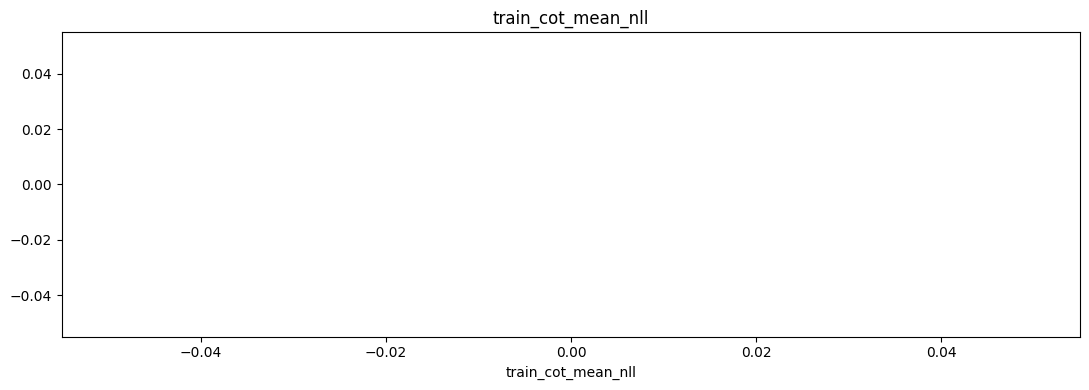

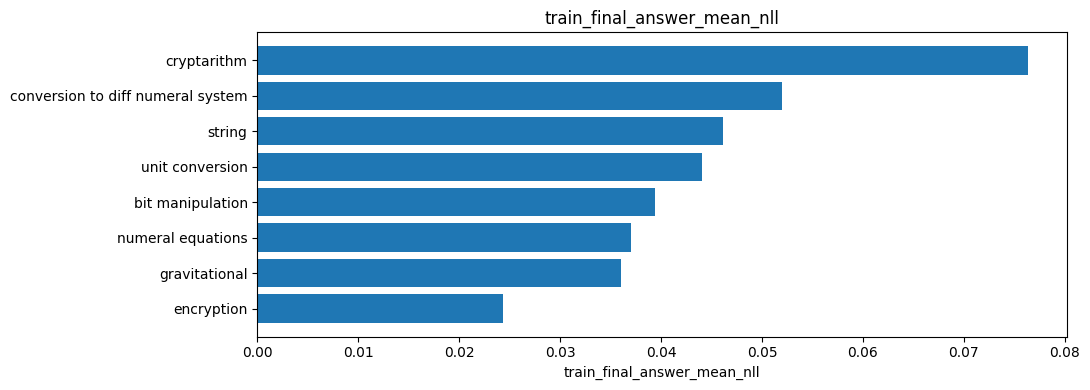

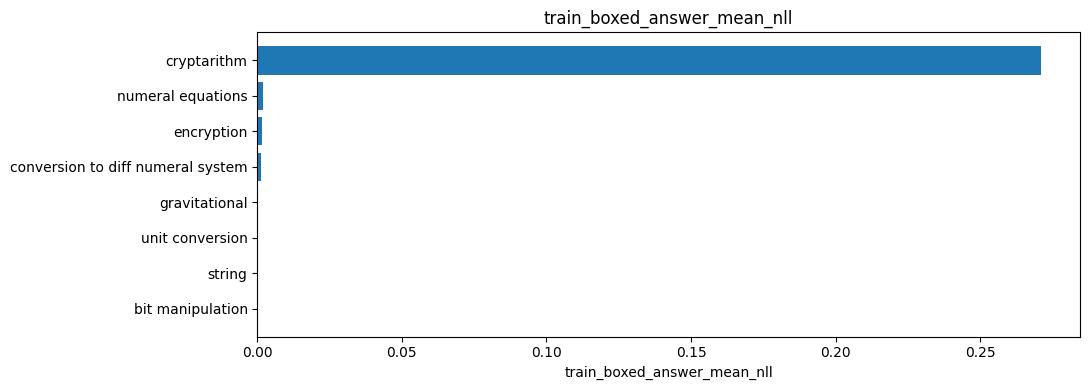

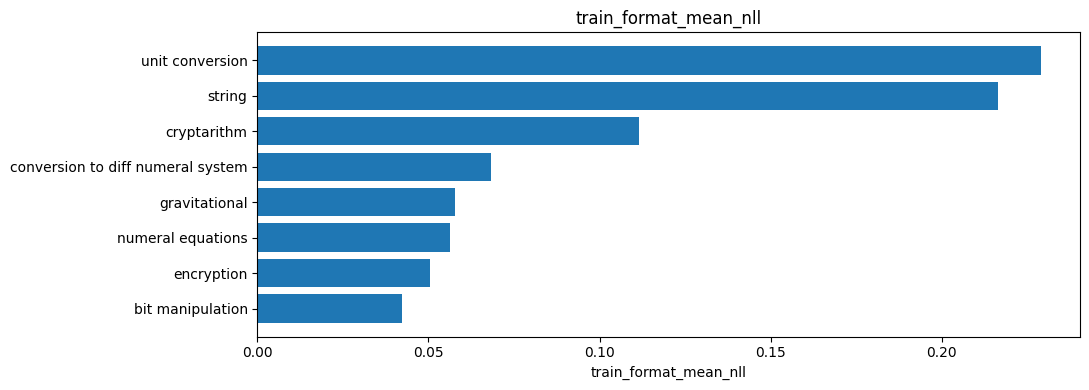

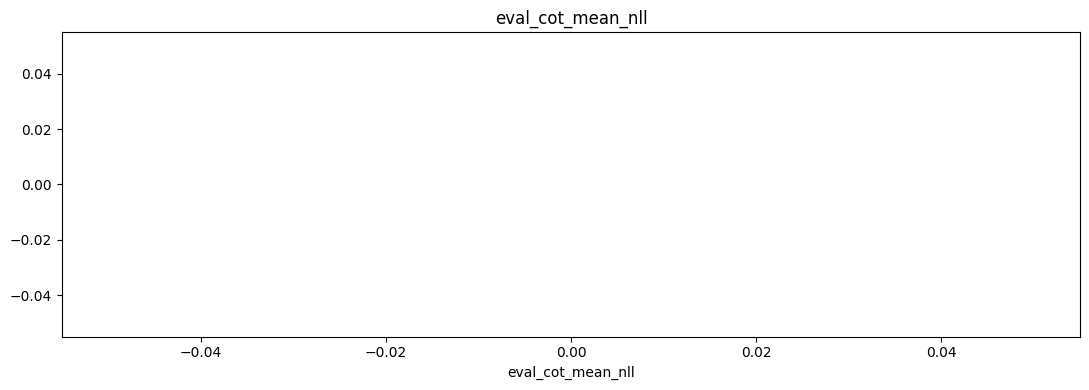

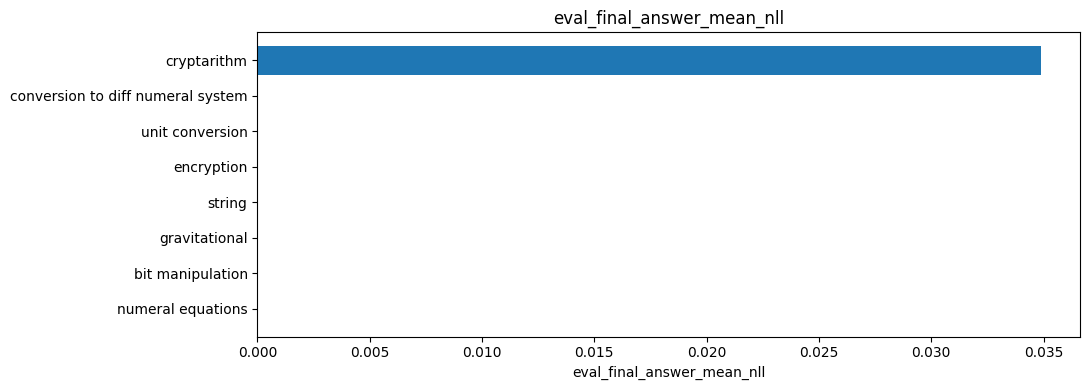

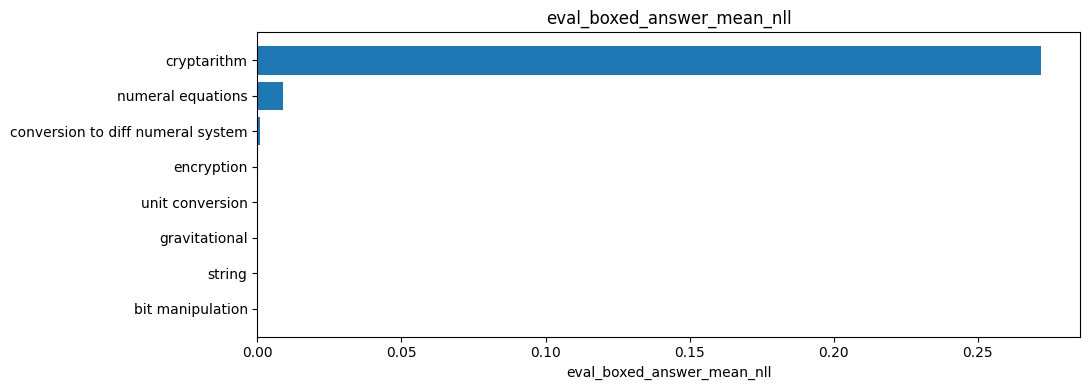

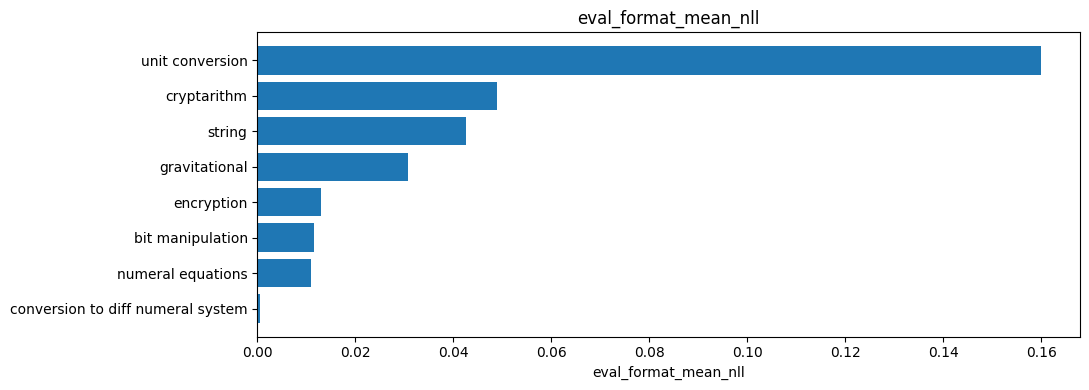

In [9]:
def plot_section_metric(prefix):
    cols = [
        f"{prefix}_cot_mean_nll",
        f"{prefix}_final_answer_mean_nll",
        f"{prefix}_boxed_answer_mean_nll",
        f"{prefix}_format_mean_nll",
    ]
    cols = [c for c in cols if c in label_cmp.columns]

    if label_cmp.empty or not cols:
        print("No section cols for", prefix)
        return

    for col in cols:
        plot_df = label_cmp[["label", col]].dropna().sort_values(col, ascending=True)
        plt.figure(figsize=(11, max(4, len(plot_df) * 0.48)))
        plt.barh(plot_df["label"], plot_df[col])
        plt.title(col)
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

plot_section_metric("train")
plot_section_metric("eval")


### Как читать section diagnostics

- `boxed_answer_mean_nll` высокий → модель плохо предсказывает сам ответ. Это лучший сигнал для усиления.
- `format_mean_nll` высокий → модель страдает от шаблона/служебных токенов. Не дублировать вслепую.
- `cot_mean_nll` высокий, но `boxed_answer_mean_nll` низкий → модель плохо повторяет reasoning trace, но answer может быть нормальный.
- `final_answer_mean_nll` высокий → проблема вокруг `Final Answer: \boxed{...}`, но не обязательно в самом числе/ответе.


## 8. Source + label

In [10]:
def prepare_by_source_label(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()

    keep = [
        "source", "label", "count", "unique_ids", "difficulty_score",
        "mean_nll", "p95_mean_nll", "hard_token_ratio", "near_zero_token_ratio",
        "cot_mean_nll", "boxed_answer_mean_nll", "format_mean_nll",
        "answer_score", "cot_score", "format_score",
        "hard_examples_ratio", "very_hard_examples_ratio", "easy_examples_ratio",
    ]
    keep = [c for c in keep if c in df.columns]

    out = df[keep].copy()
    out = out.rename(columns={c: f"{prefix}_{c}" for c in out.columns if c not in ["source", "label"]})
    return out

train_sl = prepare_by_source_label(train["by_source_label"], "train")
eval_sl = prepare_by_source_label(eval_["by_source_label"], "eval")

if not train_sl.empty and not eval_sl.empty:
    sl_cmp = train_sl.merge(eval_sl, on=["source", "label"], how="outer")
elif not train_sl.empty:
    sl_cmp = train_sl.copy()
else:
    sl_cmp = eval_sl.copy()

if not sl_cmp.empty:
    sl_cmp["decision_score"] = (
        sl_cmp.get("eval_difficulty_score", 0).fillna(0) * 2.0
        + sl_cmp.get("eval_hard_examples_ratio", 0).fillna(0) * 1.5
        + sl_cmp.get("eval_boxed_answer_mean_nll", 0).fillna(0) * 2.0
        + sl_cmp.get("train_difficulty_score", 0).fillna(0) * 1.0
    )
    sl_cmp = sl_cmp.sort_values("decision_score", ascending=False)

display(sl_cmp)


,source,label,train_count,train_unique_ids,train_difficulty_score,train_mean_nll,train_p95_mean_nll,train_hard_token_ratio,train_near_zero_token_ratio,train_cot_mean_nll,train_boxed_answer_mean_nll,train_format_mean_nll,train_answer_score,train_cot_score,train_format_score,train_hard_examples_ratio,train_very_hard_examples_ratio,train_easy_examples_ratio,eval_count,eval_unique_ids,eval_difficulty_score,eval_mean_nll,eval_p95_mean_nll,eval_hard_token_ratio,eval_near_zero_token_ratio,eval_cot_mean_nll,eval_boxed_answer_mean_nll,eval_format_mean_nll,eval_answer_score,eval_cot_score,eval_format_score,eval_hard_examples_ratio,eval_very_hard_examples_ratio,eval_easy_examples_ratio,decision_score
11,solver,unit conversion,1435,1435,0.590360,0.217368,0.748433,0.076751,0.842328,NaN,0.000059,0.228962,0.000059,0.0,0.310203,1.000000,0.683624,0.000000,954.0,159.0,0.459414,0.150724,0.220908,0.059369,0.869333,NaN,6.691736e-07,0.159920,6.691736e-07,0.0,0.222915,1.000000,0.627883,0.000000,3.009189
6,solver,cryptarithm,313,313,0.223346,0.101456,0.420080,0.030595,0.920400,NaN,0.236894,0.101488,0.282027,0.0,0.132151,0.610224,0.316294,0.000000,186.0,31.0,0.111906,0.049148,0.095461,0.017630,0.946911,NaN,2.718663e-01,0.048819,3.390706e-01,0.0,0.066445,0.408602,0.182796,0.000000,1.603794
10,solver,string,65,65,0.358484,0.202349,1.261915,0.051140,0.891021,NaN,0.000032,0.216433,0.000032,0.0,0.271378,0.353846,0.153846,0.200000,42.0,7.0,0.040327,0.039359,0.070838,0.010847,0.964086,NaN,4.846421e-07,0.042584,4.846421e-07,0.0,0.054319,0.142857,0.023810,0.261905,0.653426
1,generated,cryptarithm,1095,1095,0.262400,0.114219,0.714074,0.033374,0.914819,NaN,0.280618,0.114293,0.342249,0.0,0.147756,0.560731,0.324201,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.262400
9,solver,numeral equations,473,473,0.101205,0.049875,0.348273,0.012461,0.967710,NaN,0.000732,0.050358,0.000729,0.0,0.062970,0.078224,0.065539,0.852008,276.0,46.0,0.008771,0.010835,0.022502,0.003768,0.986555,NaN,8.853943e-03,0.011016,1.247713e-02,0.0,0.014846,0.025362,0.021739,0.894928,0.174497
5,solver,conversion to diff numeral system,1418,1418,0.125466,0.066313,0.582251,0.015528,0.966177,NaN,0.001275,0.068150,0.001627,0.0,0.084513,0.074753,0.068406,0.908322,948.0,158.0,0.000441,0.000474,0.000455,0.000101,0.999616,NaN,8.082201e-04,0.000499,1.335646e-03,0.0,0.000601,0.001055,0.001055,0.989451,0.129546
8,solver,gravitational,1437,1437,0.085737,0.056962,0.268128,0.018904,0.962276,NaN,0.000178,0.057803,0.000178,0.0,0.077089,0.068894,0.059151,0.008351,960.0,160.0,0.017466,0.030009,0.037971,0.012039,0.977942,NaN,5.150524e-07,0.030764,5.150524e-07,0.0,0.043106,0.000000,0.000000,0.007292,0.120671
3,generated,numeral equations,946,946,0.116465,0.058968,0.454419,0.014017,0.963797,NaN,0.002697,0.059476,0.002961,0.0,0.073653,0.085624,0.063425,0.806554,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.116465
2,generated,encryption,696,696,0.112987,0.058724,0.494439,0.014129,0.961918,NaN,0.002271,0.060017,0.002271,0.0,0.074503,0.089080,0.066092,0.642241,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.112987
7,solver,encryption,1406,1406,0.086362,0.044879,0.232044,0.011143,0.968332,NaN,0.001319,0.045890,0.001319,0.0,0.057322,0.071124,0.054765,0.753912,948.0,158.0,0.007532,0.012569,0.034808,0.003365,0.986084,NaN,5.042446e-05,0.013043,5.042446e-05,0.0,0.016535,0.001055,0.000000,0.770042,0.103108


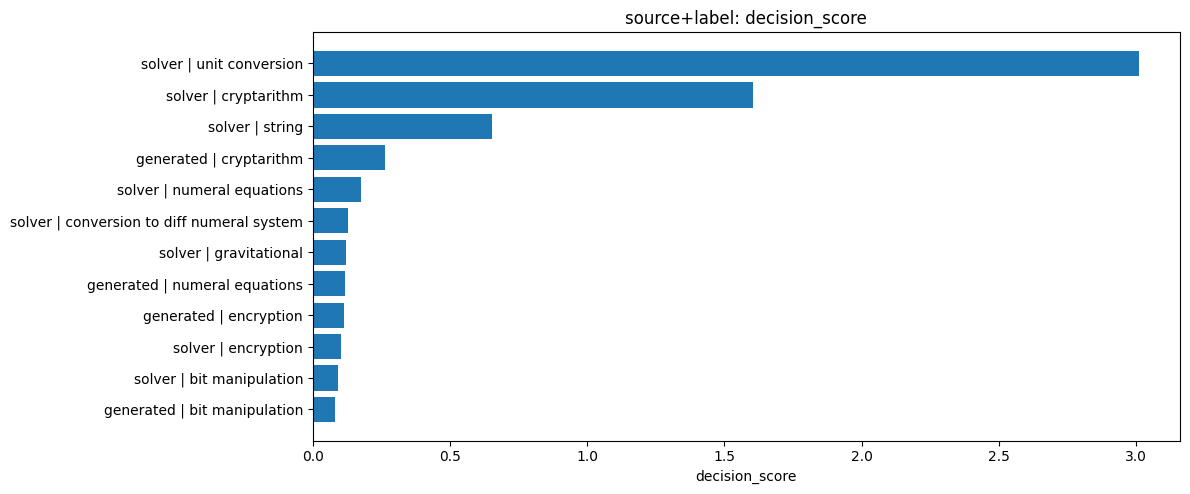

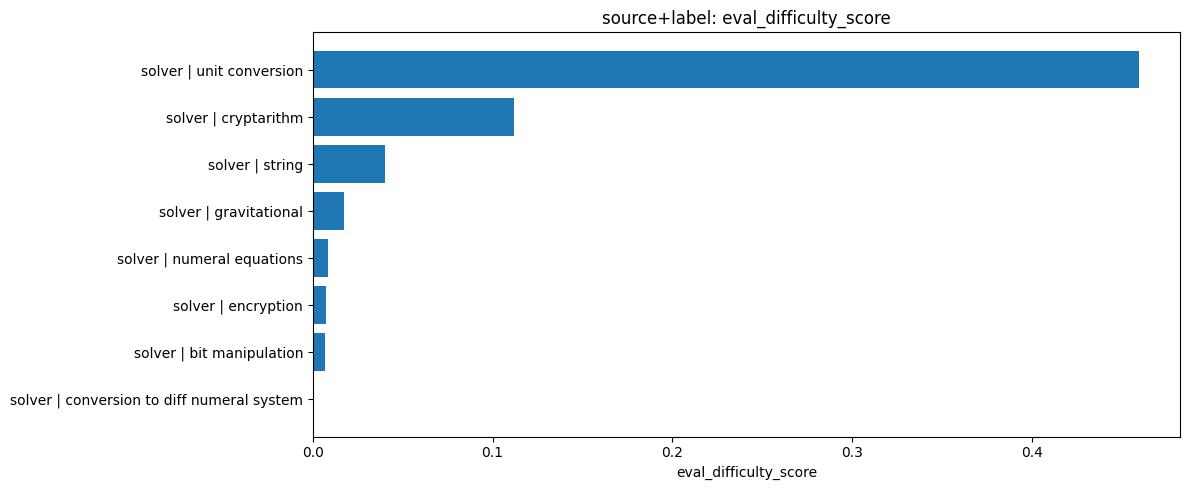

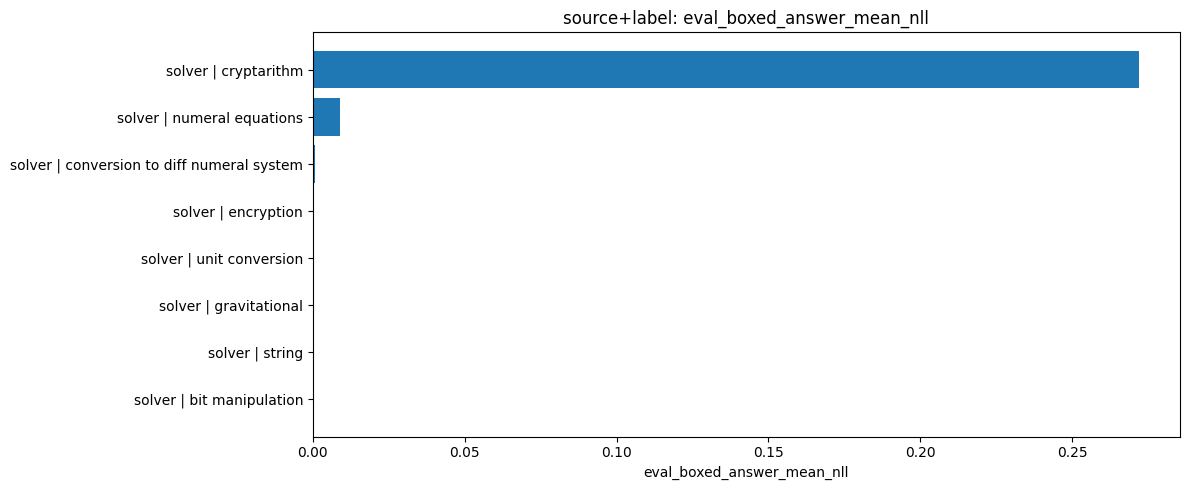

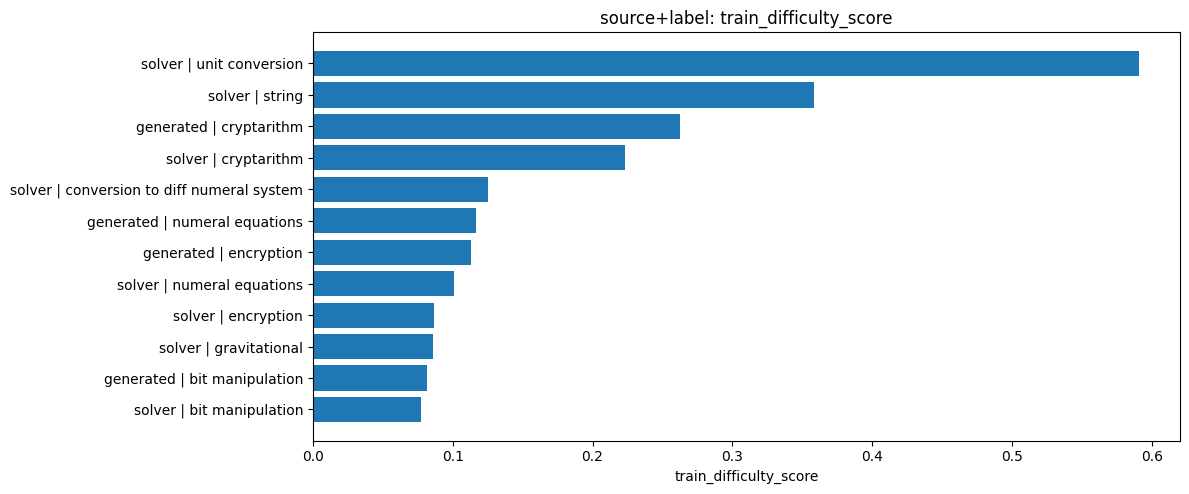

In [11]:
if not sl_cmp.empty:
    top_sl = sl_cmp.head(20).copy()
    top_sl["source_label"] = top_sl["source"].astype(str) + " | " + top_sl["label"].astype(str)

    for metric in ["decision_score", "eval_difficulty_score", "eval_boxed_answer_mean_nll", "train_difficulty_score"]:
        if metric not in top_sl.columns:
            continue
        plot_df = top_sl[["source_label", metric]].dropna().sort_values(metric, ascending=True)
        plt.figure(figsize=(12, max(5, len(plot_df) * 0.42)))
        plt.barh(plot_df["source_label"], plot_df[metric])
        plt.title("source+label: " + metric)
        plt.xlabel(metric)
        plt.tight_layout()
        plt.show()


## 9. Bad tokens

In [ ]:
bad_train = train["bad_tokens"][train["bad_tokens"].label == ].copy()
bad_eval = eval_["bad_tokens"].copy()

if bad_train.empty:
    print("train bad_tokens is empty. Скорее всего, SFT запускался старой telemetry без top_bad_tokens.")
else:
    print("Top train bad tokens")
    display(bad_train.head(80))

if bad_eval.empty:
    print("eval bad_tokens is empty.")
else:
    print("Top eval bad tokens")
    display(bad_eval.head(80))


Top train bad tokens


,source,label,section,token_text,count,mean_logprob,min_logprob,mean_nll,sample_context_1,sample_context_2,sample_context_3
0,solver,conversion to diff numeral system,format,\n,1245,-0.023824,-2.237878,0.023824,89 -> LXXXIX\n 13 -> XIII\n\nThe,III\n 11 -> XI\n 59 -> LIX\n\n,\n 53 -> LIII\n 31 -> XXXI\n\n
1,solver,bit manipulation,format,in,944,-1.125615,-16.503437,1.125615,0101110; in[2] gives 111,1100000; in[0] gives 010,1111011; in[3] gives 100
2,solver,encryption,format,'.\n\n,867,-1.180532,-11.760767,1.180532,"='t', 'j'='h'.\n\nAnalyzing Example 2: 'q","dragon chases the secret ke?'.\n\nSince some letters are still unknown, we","z' -> 'mouse chases garden'.\n\nCombining these extracted rules, we establish"
3,solver,unit conversion,format,6,827,-2.717037,-9.579698,2.717037,"5 implies ratio in [1.06016421,","ratio in [1.49864100, 1.",25.614326]\nBoth bounds round to exactly 2
4,solver,encryption,format,'.\n,804,-1.002536,-16.000378,1.002536,decryption: 'student writes inside mountain'.\nThe final fully decrypted text is complete,"='k', 'd'='g'.\nWord 'nxbdnhem' (",ryption: 'teacher draws the magical story'.\nThe final fully decrypted text is complete
...,...,...,...,...,...,...,...,...,...,...,...
75,generated,numeral equations,format,the,154,-1.695656,-8.625394,1.695656,", and avoids rare transformations unless needed; the selected operator-specific format is kept because the",", and avoids rare transformations unless needed; the selected operator-specific format is kept because the",", and avoids rare transformations unless needed; the selected operator-specific format is kept because the"
76,solver,encryption,format,?,149,-1.156548,-7.947869,1.156548,partial decryption: 'stu?ent ?raws the curious ke?'.\n\nSince,a partial decryption: 'the wise ?ueen watches'.\n\nSince some letters are,decryption: 'alice follows around ?alley'.\n\nSince some letters are still
77,solver,encryption,format,"',",143,-1.804181,-8.452750,1.804181,"Extracted: 'z'='y', 'e'='l'.\n\nAnalyzing","Extracted: 'p'='b', 's'='k'.\n\nCombining","='y', 'i'='t', 't'='l'.\n\nAnalyzing"
78,generated,bit manipulation,format,2,142,-2.039648,-9.007044,2.039648,"-NOT(in[0], in[2]) gives 01000",])\n\nPattern summary:\nout[0..2] use a shifted AND-NOT pattern,"11; OR-NOT(in[2], in[3]) gives 0"


Top eval bad tokens


,source,label,section,token_text,count,mean_logprob,min_logprob,mean_nll,sample_context_1,sample_context_2,sample_context_3
0,solver,conversion to diff numeral system,format,\n,943,-0.004535,-1.313270,0.004535,\n 42 -> XLII\n 8 -> VIII\n\nThe output,\n 35 -> XXXV\n 98 -> XCVIII,75 -> LXXV\n 97 -> XCVII
1,solver,encryption,format,'.\n,680,-0.863791,-7.501222,0.863791,"='u', 'l'='i'.\nWord 'xfvgznh' (",decryption: 'the bright bird explores'.\nThe final fully decrypted text is complete,' -> 'cat found the magical mirror'.\nWord 'wtbsa' (5
2,solver,unit conversion,format,4,617,-2.687768,-8.001922,2.687768,19.852346]\nBoth bounds round to exactly,"boundaries: [22.804389, 22.",22.808414]\nAmbiguity detected (bounds
3,solver,bit manipulation,format,in,610,-1.009471,-6.018478,1.009471,1001111; in[3] gives 010,1011100; in[2] gives 111,1011100; in[5] gives 000
4,solver,unit conversion,format,2,583,-2.681665,-6.661153,2.681665,": [33.045275, 33.0","5, 1.04321561]\n 3","9, 31.092719]\nBoth bounds round to"
...,...,...,...,...,...,...,...,...,...,...,...
75,solver,string,format,The,60,-1.965410,-4.760165,1.965410,The target operator in the expression is '/'.\n,The target operator in the expression is '*',The target operator in the expression is '^
76,solver,conversion to diff numeral system,format,9,60,-0.005975,-0.102672,0.005975,9.\n - Subtract 9 (IX): remainder is 0.\n\n,9.\n - Subtract 9 (IX): remainder is 0.\n\n,9.\n - Subtract 9 (IX): remainder is 0.\n\n
77,solver,conversion to diff numeral system,format,X,59,-0.001787,-0.035678,0.001787,.\n\nCombining the symbols gives us: XLI.\nThe final answer is XLI,: XLI.\nThe final answer is XLI.\n</think>\nFinal Answer: \,XLVII.\nThe final answer is XLVII.\n</think>\nFinal Answer:
78,solver,cryptarithm,format,3,57,-2.548384,-5.132315,2.548384,"%` - /` -> A=32, B=31;","-> A=30, B=39; 30 + 3",") * <"" -> A=43, B=50; 4"


In [13]:
def section_summary(bad_df):
    if bad_df.empty or "section" not in bad_df.columns:
        return pd.DataFrame()

    out = bad_df.groupby("section", dropna=False).agg(
        rows=("token_text", "count"),
        total_count=("count", "sum"),
        mean_token_nll=("mean_nll", "mean"),
        worst_logprob=("min_logprob", "min"),
    ).reset_index().sort_values("total_count", ascending=False)

    total = out["total_count"].sum()
    if total > 0:
        out["count_share"] = out["total_count"] / total

    return out

train_section_summary = section_summary(bad_train)
eval_section_summary = section_summary(bad_eval)

print("TRAIN bad token sections")
display(train_section_summary)

print("EVAL bad token sections")
display(eval_section_summary)


TRAIN bad token sections


,section,rows,total_count,mean_token_nll,worst_logprob,count_share
2,format,3246,54128,3.337064,-26.084991,0.979692
0,boxed_answer,58,671,3.166081,-11.001880,0.012145
1,final_answer,26,451,5.620513,-13.332965,0.008163


EVAL bad token sections


,section,rows,total_count,mean_token_nll,worst_logprob,count_share
2,format,785,24960,1.817945,-17.812553,0.975381
0,boxed_answer,13,409,1.417838,-6.948503,0.015983
1,final_answer,5,221,2.804593,-8.150354,0.008636


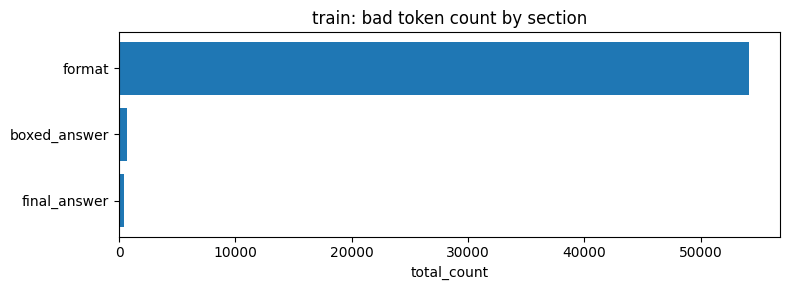

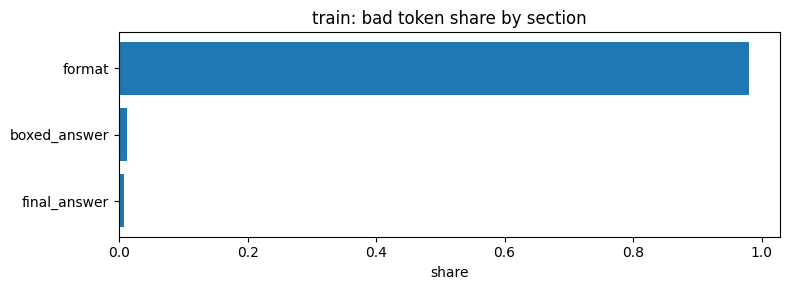

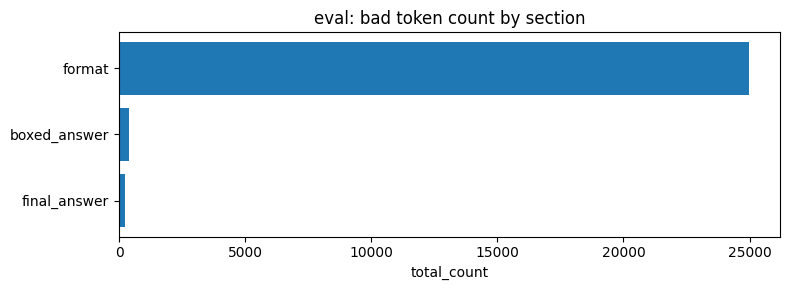

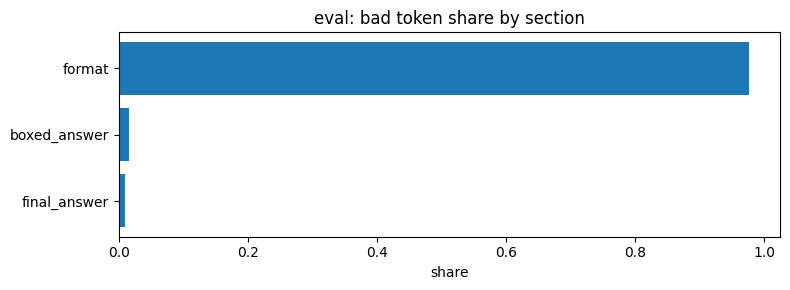

In [14]:
for name, df in [("train", train_section_summary), ("eval", eval_section_summary)]:
    if df.empty:
        continue

    plot_df = df.sort_values("total_count", ascending=True)

    plt.figure(figsize=(8, max(3, len(plot_df) * 0.6)))
    plt.barh(plot_df["section"], plot_df["total_count"])
    plt.title(f"{name}: bad token count by section")
    plt.xlabel("total_count")
    plt.tight_layout()
    plt.show()

    if "count_share" in plot_df.columns:
        plt.figure(figsize=(8, max(3, len(plot_df) * 0.6)))
        plt.barh(plot_df["section"], plot_df["count_share"])
        plt.title(f"{name}: bad token share by section")
        plt.xlabel("share")
        plt.tight_layout()
        plt.show()


### Ключ к bad tokens

Если много плохих токенов в `format`, это может быть ложная hardness: модель страдает от формата, а не от задачи.

Если плохие токены в `boxed_answer`, это уже ближе к реальной ошибке решения.

Если плохие токены в `cot`, смотри context:
- decimal boundaries / ambiguity / infinite precision → возможно слишком шумный CoT;
- operation/reasoning/derived value → может быть настоящая reasoning-hardness.


## 10. Bad tokens by label and section

In [15]:
def bad_tokens_by_label_section(bad_df, name):
    if bad_df.empty:
        print(name, "bad tokens empty")
        return pd.DataFrame()

    out = bad_df.groupby(["label", "section"], dropna=False).agg(
        rows=("token_text", "count"),
        total_count=("count", "sum"),
        mean_token_nll=("mean_nll", "mean"),
        worst_logprob=("min_logprob", "min"),
    ).reset_index()

    out = out.sort_values(["total_count", "mean_token_nll"], ascending=[False, False])
    print(name)
    display(out.head(80))
    return out

train_bad_label_section = bad_tokens_by_label_section(bad_train, "TRAIN bad tokens by label/section")
eval_bad_label_section = bad_tokens_by_label_section(bad_eval, "EVAL bad tokens by label/section")


TRAIN bad tokens by label/section


,label,section,rows,total_count,mean_token_nll,worst_logprob
10,encryption,format,1721,10480,2.481993,-19.545822
1,bit manipulation,format,124,8829,3.899915,-20.136911
19,unit conversion,format,24,7157,6.209485,-17.299799
12,gravitational,format,23,7153,5.034587,-26.084991
15,numeral equations,format,254,7092,3.980402,-20.125980
7,cryptarithm,format,961,6946,4.797423,-20.040678
4,conversion to diff numeral system,format,82,6148,0.446822,-15.197179
2,conversion to diff numeral system,boxed_answer,12,615,0.011936,-1.318447
3,conversion to diff numeral system,final_answer,2,327,3.775513,-13.236446
17,string,format,57,323,2.705336,-13.176606


EVAL bad tokens by label/section


,label,section,rows,total_count,mean_token_nll,worst_logprob
8,gravitational,format,10,4800,2.343963,-11.134445
12,unit conversion,format,11,4770,2.718431,-8.600346
7,encryption,format,443,4740,1.613474,-17.812553
3,conversion to diff numeral system,format,72,4137,0.005615,-6.751555
0,bit manipulation,format,34,4020,1.582249,-13.361643
10,numeral equations,format,58,1375,1.919414,-13.119132
6,cryptarithm,format,126,908,3.516476,-10.632668
1,conversion to diff numeral system,boxed_answer,8,390,0.025995,-1.140783
2,conversion to diff numeral system,final_answer,2,213,0.000687,-0.023452
11,string,format,31,210,1.624923,-8.393079


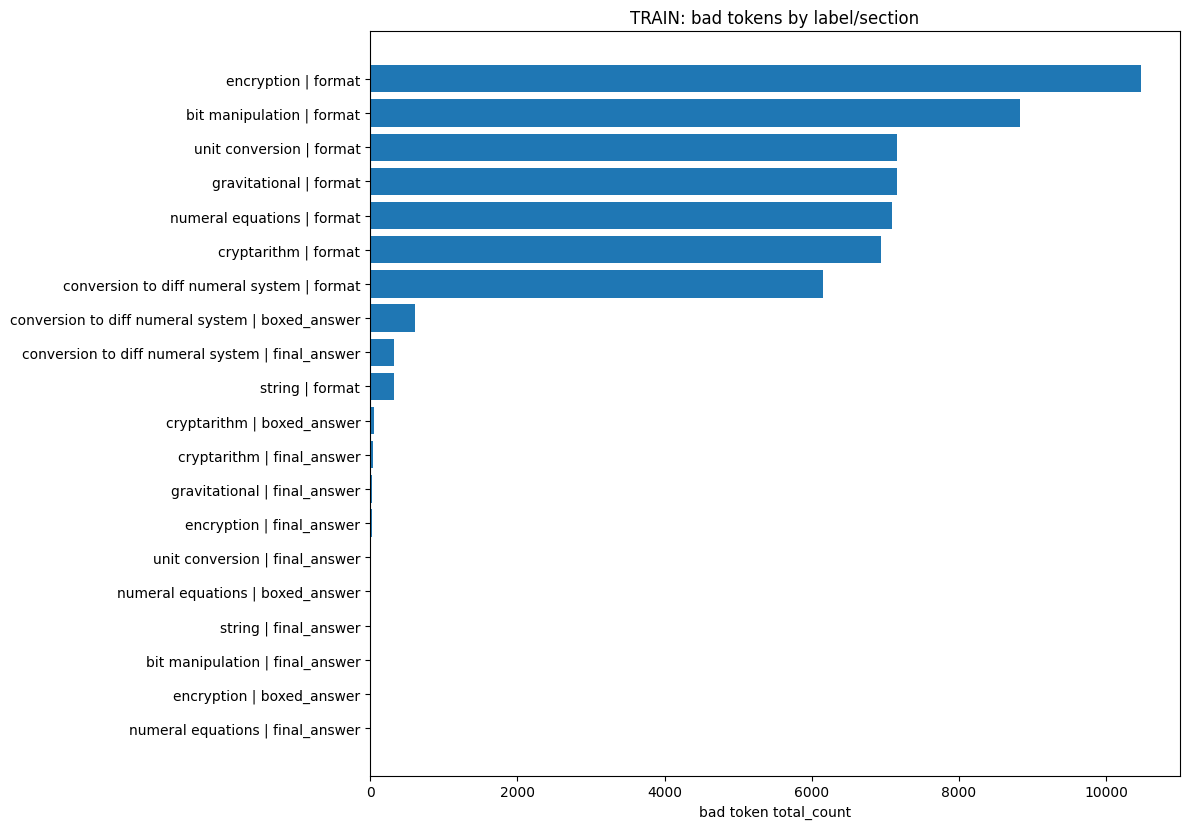

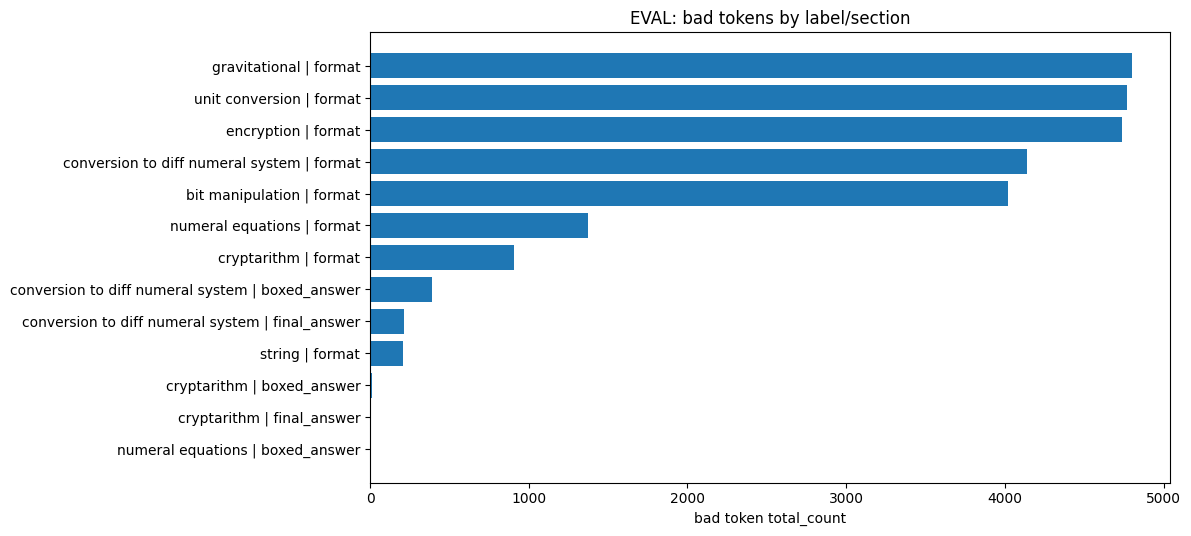

In [16]:
def plot_bad_label_section(df, title):
    if df.empty:
        return

    top = df.head(25).copy()
    top["label_section"] = top["label"].astype(str) + " | " + top["section"].astype(str)
    top = top.sort_values("total_count", ascending=True)

    plt.figure(figsize=(12, max(5, len(top) * 0.42)))
    plt.barh(top["label_section"], top["total_count"])
    plt.title(title)
    plt.xlabel("bad token total_count")
    plt.tight_layout()
    plt.show()

plot_bad_label_section(train_bad_label_section, "TRAIN: bad tokens by label/section")
plot_bad_label_section(eval_bad_label_section, "EVAL: bad tokens by label/section")


## 11. Checkpoint dynamics from raw telemetry

In [17]:
def read_jsonl_files(root: Path) -> pd.DataFrame:
    files = sorted(root.rglob("*.jsonl"))
    rows = []

    for path in files:
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    for col in [
        "checkpoint_bucket", "step", "mean_nll", "p05_logprob", "hard_token_ratio",
        "near_zero_token_ratio", "boxed_answer_mean_nll", "cot_mean_nll", "format_mean_nll"
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

train_raw = read_jsonl_files(TRAIN_TELEMETRY_DIR) if TRAIN_TELEMETRY_DIR.exists() else pd.DataFrame()
eval_raw = read_jsonl_files(EVAL_TELEMETRY_DIR) if EVAL_TELEMETRY_DIR.exists() else pd.DataFrame()

print("train_raw:", train_raw.shape)
print("eval_raw:", eval_raw.shape)


train_raw: (11050, 40)
eval_raw: (5118, 40)


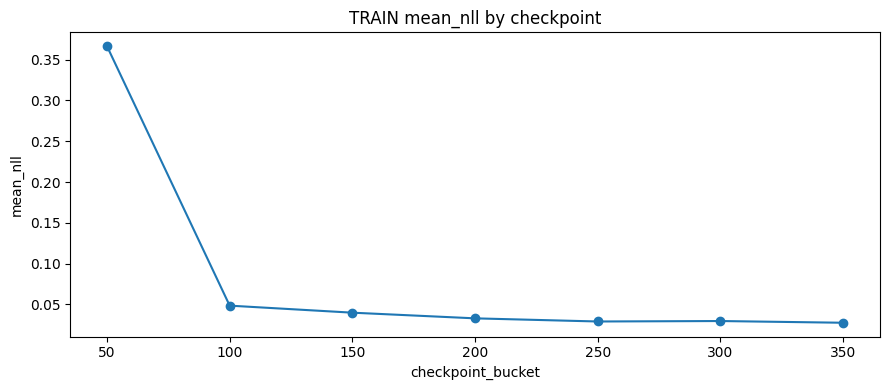

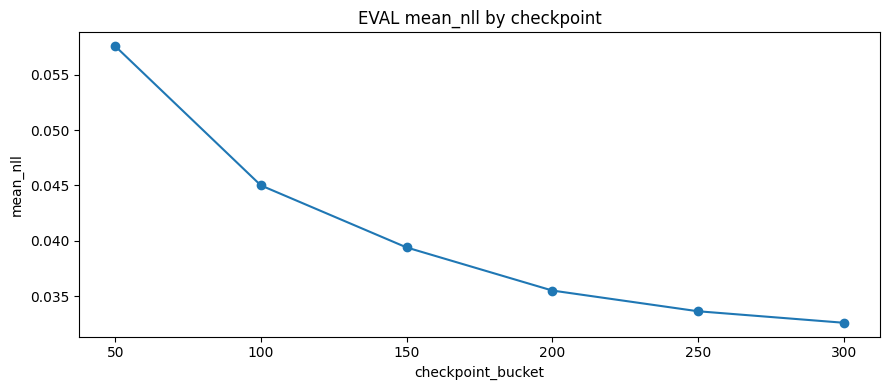

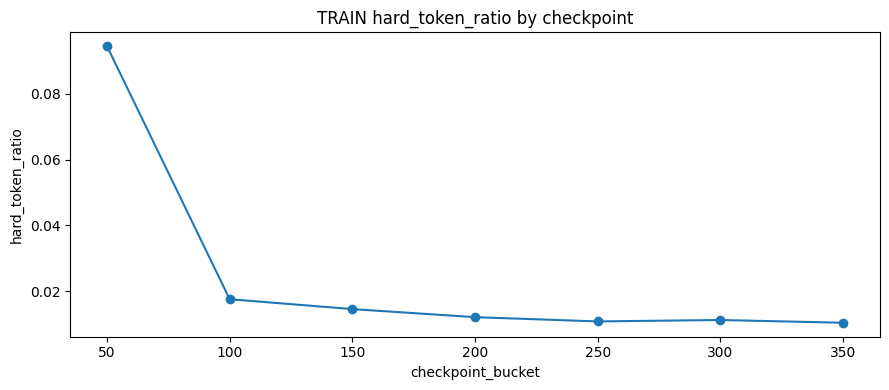

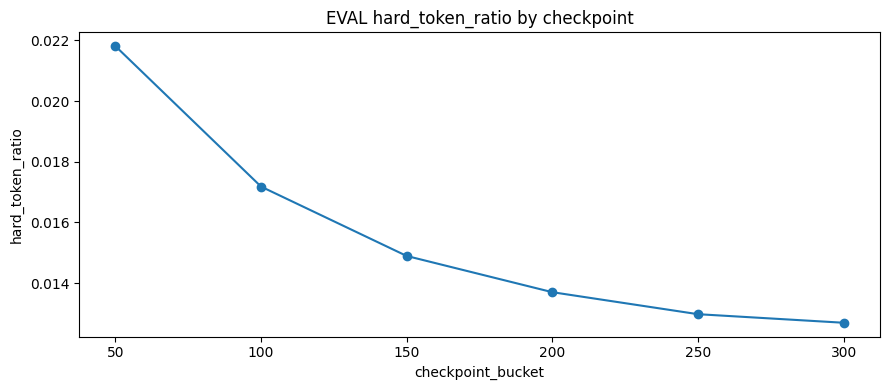

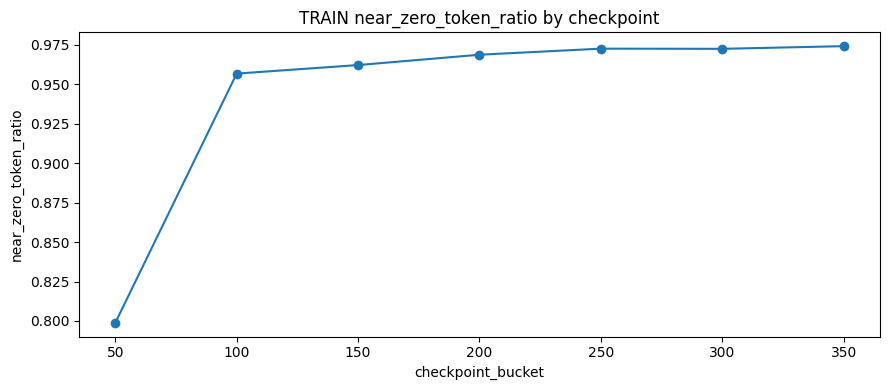

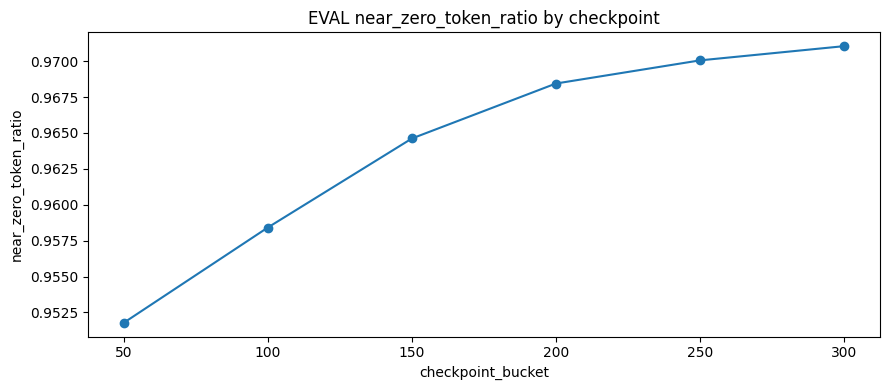

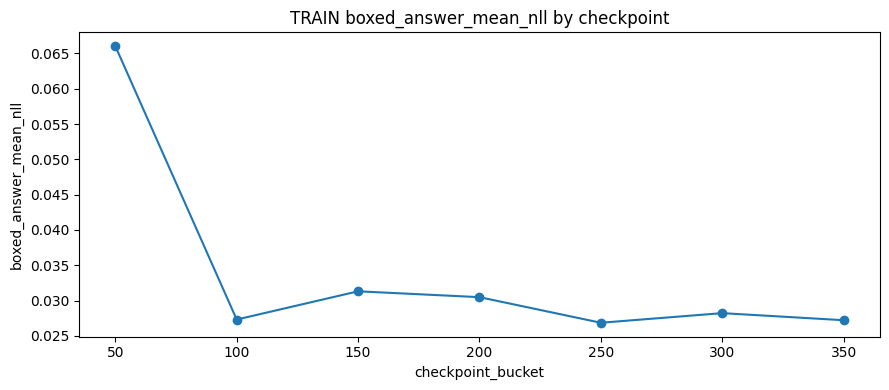

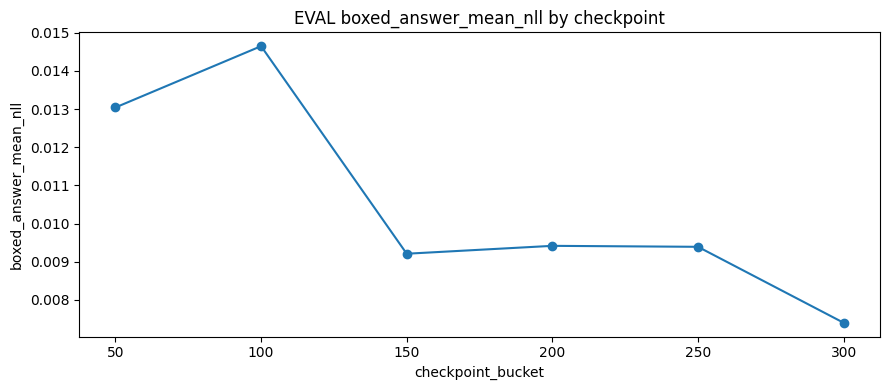

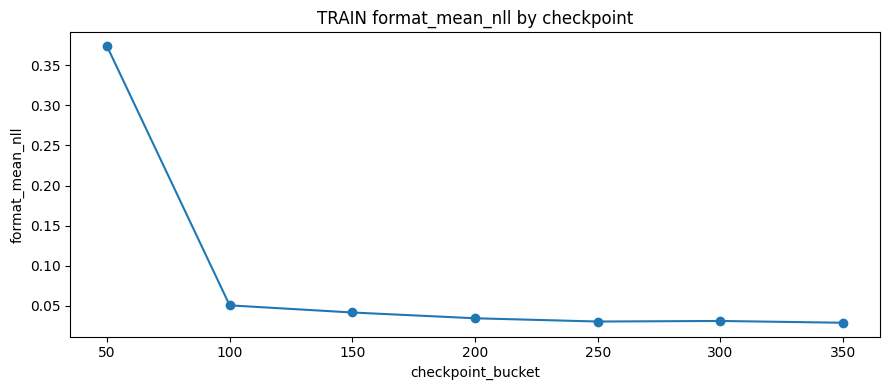

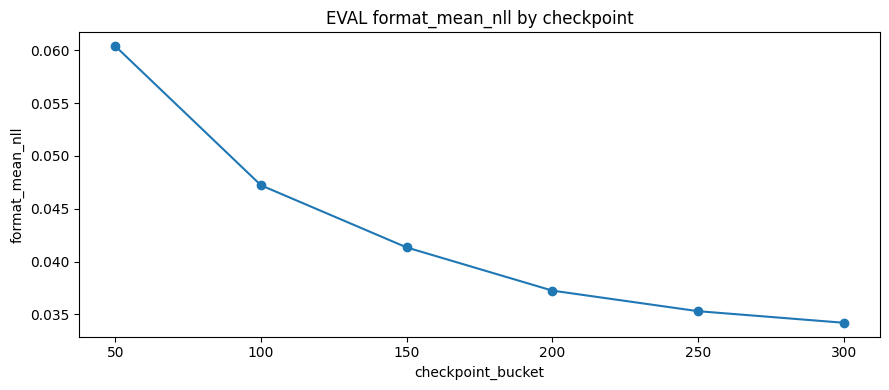

In [18]:
def plot_checkpoint_metric(raw_df, metric, title):
    if raw_df.empty or metric not in raw_df.columns or "checkpoint_bucket" not in raw_df.columns:
        print("No data for", title)
        return

    by_ckpt = raw_df.groupby("checkpoint_bucket", dropna=False)[metric].mean().reset_index()
    by_ckpt = by_ckpt.sort_values("checkpoint_bucket")

    plt.figure(figsize=(9, 4))
    plt.plot(by_ckpt["checkpoint_bucket"], by_ckpt[metric], marker="o")
    plt.title(title)
    plt.xlabel("checkpoint_bucket")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

for metric in ["mean_nll", "hard_token_ratio", "near_zero_token_ratio", "boxed_answer_mean_nll", "format_mean_nll"]:
    plot_checkpoint_metric(train_raw, metric, "TRAIN " + metric + " by checkpoint")
    plot_checkpoint_metric(eval_raw, metric, "EVAL " + metric + " by checkpoint")


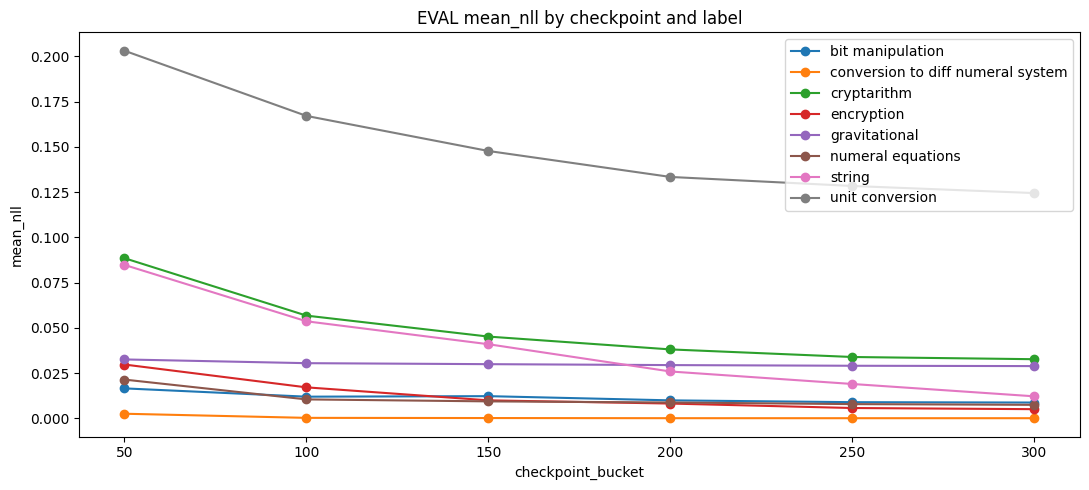

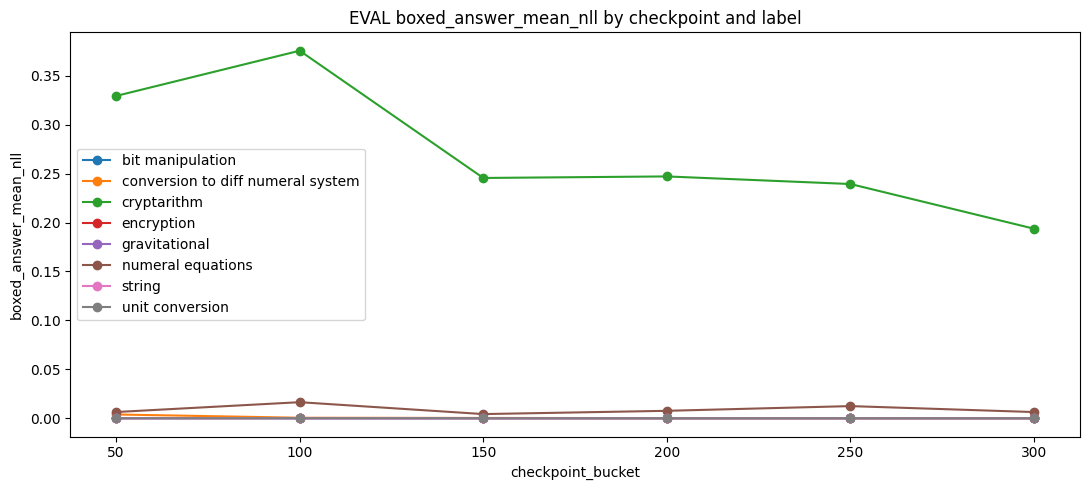

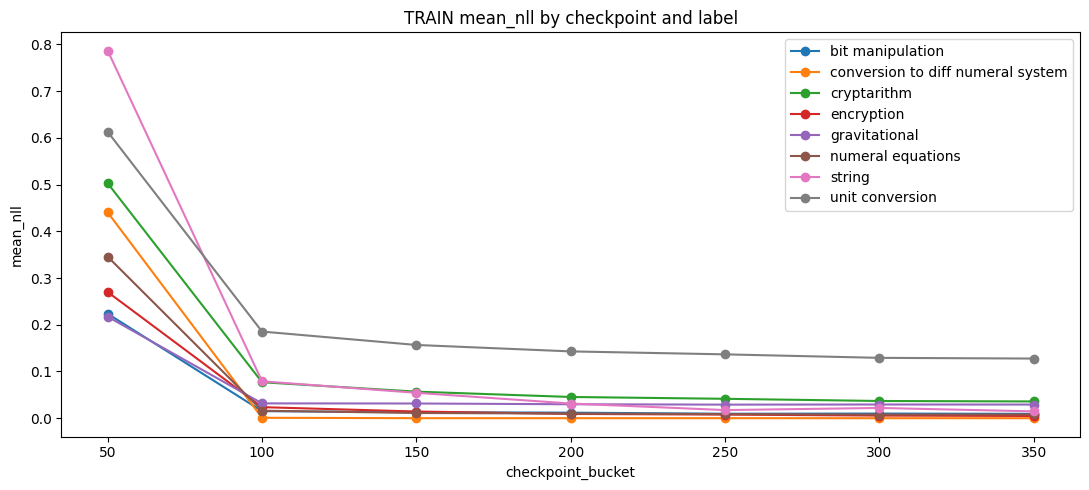

In [19]:
def plot_checkpoint_metric_by_label(raw_df, metric, top_labels=None, title=None):
    if raw_df.empty or metric not in raw_df.columns:
        print("No data for", title or metric)
        return

    if top_labels is None:
        if "label" not in raw_df.columns:
            return
        top_labels = raw_df.groupby("label")[metric].mean().sort_values(ascending=False).head(8).index.tolist()

    use_df = raw_df[raw_df["label"].isin(top_labels)].copy()
    pivot = use_df.groupby(["checkpoint_bucket", "label"])[metric].mean().reset_index()

    plt.figure(figsize=(11, 5))
    for label, group in pivot.groupby("label"):
        group = group.sort_values("checkpoint_bucket")
        plt.plot(group["checkpoint_bucket"], group[metric], marker="o", label=str(label))
    plt.title(title or metric)
    plt.xlabel("checkpoint_bucket")
    plt.ylabel(metric)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_checkpoint_metric_by_label(eval_raw, "mean_nll", title="EVAL mean_nll by checkpoint and label")
plot_checkpoint_metric_by_label(eval_raw, "boxed_answer_mean_nll", title="EVAL boxed_answer_mean_nll by checkpoint and label")
plot_checkpoint_metric_by_label(train_raw, "mean_nll", title="TRAIN mean_nll by checkpoint and label")


### Как читать dynamics

- eval `mean_nll` падает по checkpoint → модель реально обобщает.
- train падает, eval стоит → запоминание train traces.
- eval `boxed_answer_mean_nll` не падает → модель не учится выдавать ответ, даже если общий loss падает.


## 12. Boxed answer sequence metrics for exact-match tasks

Для задач вроде `bit manipulation` средний loss по answer может обманывать.

Пример: если answer состоит из 8 битов и модель ошибается в 1 бите, exact match уже неверный, но `boxed_answer_mean_nll` может выглядеть умеренно.

Поэтому добавляем sequence-level метрики:

```text
boxed_answer_total_nll = boxed_answer_mean_nll * boxed_answer_num_tokens
boxed_answer_sequence_prob_est = exp(-boxed_answer_total_nll)
```

Как читать:

| Метрика | Что значит |
|---|---|
| `boxed_answer_total_nll > 0.8` | whole answer уже заметно рискованный |
| `boxed_answer_total_nll > 1.6` | whole answer очень рискованный |
| `boxed_answer_sequence_prob_est < 0.45` | вероятность целиком правильно выдать ответ низкая |
| `boxed_answer_sequence_prob_est < 0.20` | очень низкая вероятность полного ответа |

Это особенно важно для `bit manipulation`, где один неправильный бит ломает весь ответ.


In [20]:
def add_boxed_sequence_metrics(raw_df: pd.DataFrame) -> pd.DataFrame:
    if raw_df.empty:
        return pd.DataFrame()

    required = ["label", "boxed_answer_mean_nll", "boxed_answer_num_tokens"]
    missing = [c for c in required if c not in raw_df.columns]
    if missing:
        print("Missing boxed sequence columns:", missing)
        return pd.DataFrame()

    out = raw_df.copy()

    for col in ["boxed_answer_mean_nll", "boxed_answer_num_tokens", "checkpoint_bucket"]:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    out["boxed_answer_total_nll"] = out["boxed_answer_mean_nll"].fillna(0) * out["boxed_answer_num_tokens"].fillna(0)
    out["boxed_answer_sequence_prob_est"] = np.exp(-out["boxed_answer_total_nll"].clip(lower=0, upper=50))

    return out

train_seq_raw = add_boxed_sequence_metrics(train_raw)
eval_seq_raw = add_boxed_sequence_metrics(eval_raw)

print("train_seq_raw:", train_seq_raw.shape)
print("eval_seq_raw:", eval_seq_raw.shape)


train_seq_raw: (11050, 42)
eval_seq_raw: (5118, 42)


In [21]:
def summarize_boxed_sequence(raw_df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    if raw_df.empty:
        return pd.DataFrame()

    out = raw_df.groupby("label", dropna=False).agg(
        boxed_answer_num_tokens_mean=("boxed_answer_num_tokens", "mean"),
        boxed_answer_total_nll_mean=("boxed_answer_total_nll", "mean"),
        boxed_answer_total_nll_p50=("boxed_answer_total_nll", "median"),
        boxed_answer_total_nll_p95=("boxed_answer_total_nll", lambda x: x.quantile(0.95)),
        boxed_answer_sequence_prob_mean=("boxed_answer_sequence_prob_est", "mean"),
        boxed_answer_sequence_prob_p50=("boxed_answer_sequence_prob_est", "median"),
        boxed_answer_mean_nll_mean=("boxed_answer_mean_nll", "mean"),
        count=("id", "count") if "id" in raw_df.columns else ("label", "count"),
    ).reset_index()

    out = out.rename(columns={c: f"{prefix}_{c}" for c in out.columns if c != "label"})
    return out

train_boxed_seq = summarize_boxed_sequence(train_seq_raw, "train")
eval_boxed_seq = summarize_boxed_sequence(eval_seq_raw, "eval")

if not train_boxed_seq.empty and not eval_boxed_seq.empty:
    boxed_seq_cmp = train_boxed_seq.merge(eval_boxed_seq, on="label", how="outer")
elif not train_boxed_seq.empty:
    boxed_seq_cmp = train_boxed_seq.copy()
else:
    boxed_seq_cmp = eval_boxed_seq.copy()

if not boxed_seq_cmp.empty:
    sort_col = "eval_boxed_answer_total_nll_mean" if "eval_boxed_answer_total_nll_mean" in boxed_seq_cmp.columns else "train_boxed_answer_total_nll_mean"
    boxed_seq_cmp = boxed_seq_cmp.sort_values(sort_col, ascending=False)

    # add to main decision table, so suggested weights can use it
    extra_cols = [c for c in boxed_seq_cmp.columns if c != "label"]
    label_cmp = label_cmp.merge(boxed_seq_cmp[["label"] + extra_cols], on="label", how="left")

print("Boxed sequence metrics by label")
display(boxed_seq_cmp)


Boxed sequence metrics by label


,label,train_boxed_answer_num_tokens_mean,train_boxed_answer_total_nll_mean,train_boxed_answer_total_nll_p50,train_boxed_answer_total_nll_p95,train_boxed_answer_sequence_prob_mean,train_boxed_answer_sequence_prob_p50,train_boxed_answer_mean_nll_mean,train_count,eval_boxed_answer_num_tokens_mean,eval_boxed_answer_total_nll_mean,eval_boxed_answer_total_nll_p50,eval_boxed_answer_total_nll_p95,eval_boxed_answer_sequence_prob_mean,eval_boxed_answer_sequence_prob_p50,eval_boxed_answer_mean_nll_mean,eval_count
2,cryptarithm,2.036222,0.505291,0.074621,2.633893,0.778158,0.928095,0.270984,1408,2.064516,0.522434,3.407880e-02,4.501198,0.826601,0.966495,2.718663e-01,186
5,numeral equations,2.808316,0.007095,0.000001,0.005182,0.996624,0.999999,0.002044,1419,2.847826,0.017709,5.960464e-07,0.000015,0.988548,0.999999,8.853943e-03,276
1,conversion to diff numeral system,2.245416,0.002633,0.000076,0.006707,0.997866,0.999924,0.001275,1418,2.094937,0.001629,3.105355e-05,0.001930,0.998859,0.999969,8.082201e-04,948
3,encryption,4.983825,0.007995,0.000058,0.029925,0.993061,0.999942,0.001634,2102,4.708861,0.000233,2.562980e-05,0.000909,0.999768,0.999974,5.042446e-05,948
7,unit conversion,4.905923,0.000286,0.000001,0.000886,0.999718,0.999999,0.000059,1435,4.930818,0.000003,1.072883e-06,0.000012,0.999997,0.999999,6.691736e-07,954
4,gravitational,5.148225,0.000916,0.000001,0.005534,0.999099,0.999999,0.000178,1437,5.125000,0.000003,8.344649e-07,0.000008,0.999997,0.999999,5.150524e-07,960
6,string,4.000000,0.000127,0.000001,0.000852,0.999873,0.999999,0.000032,65,4.000000,0.000002,8.344649e-07,0.000008,0.999998,0.999999,4.846421e-07,42
0,bit manipulation,8.000000,0.000072,0.000001,0.000381,0.999928,0.999999,0.000009,1766,8.000000,0.000002,1.072883e-06,0.000006,0.999998,0.999999,2.238509e-07,804


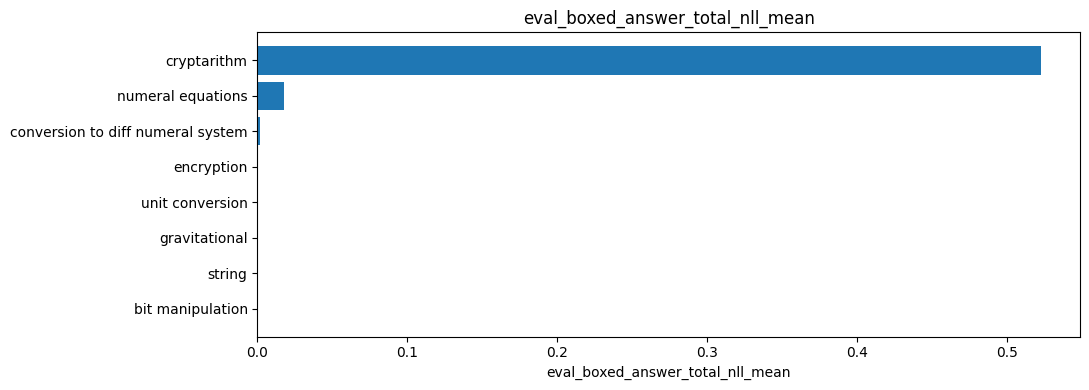

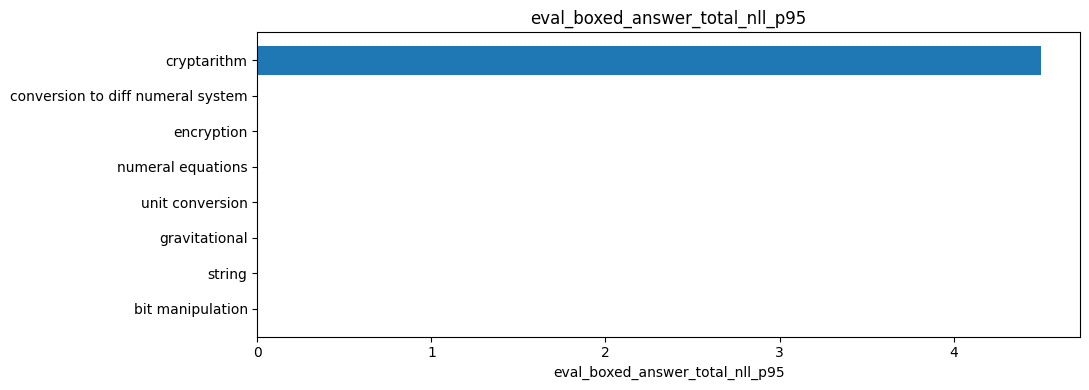

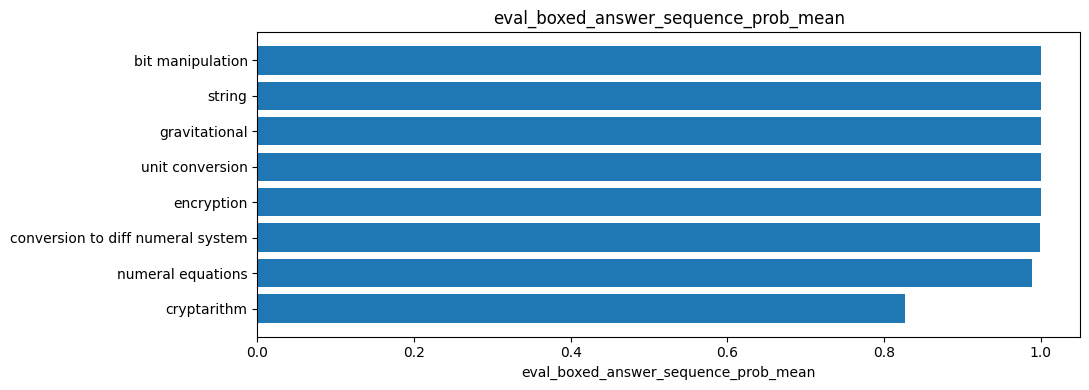

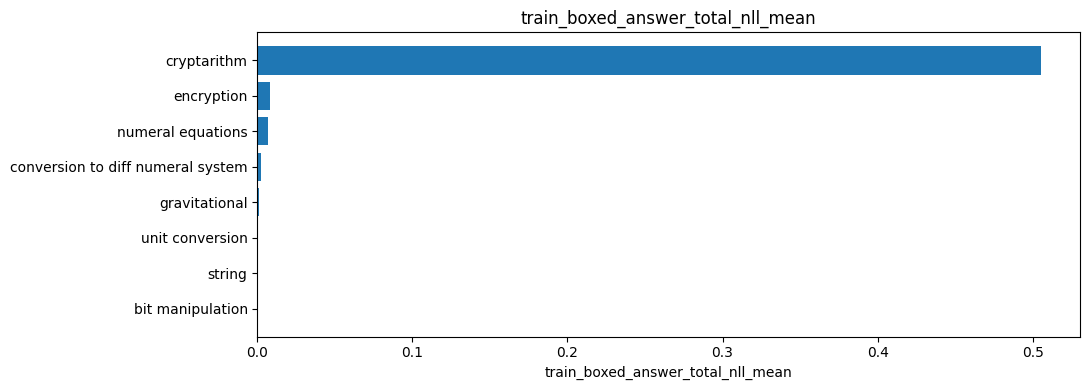

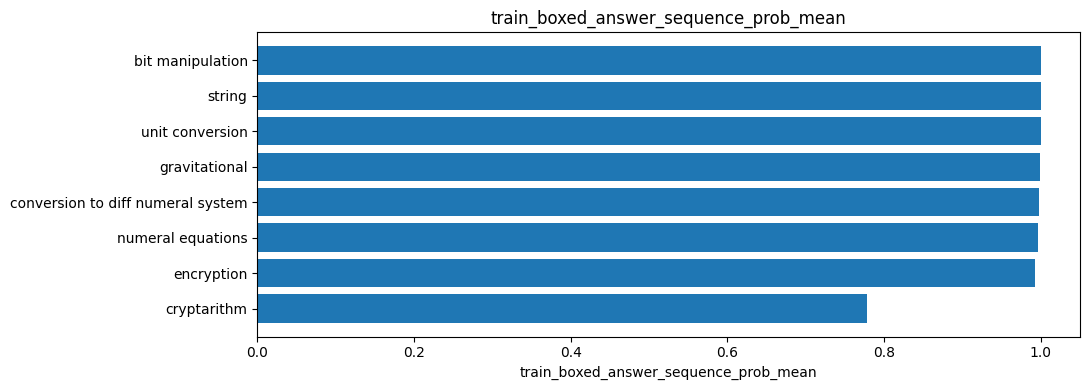

In [22]:
def plot_boxed_sequence_metric(df: pd.DataFrame, metric: str, title: str):
    if df.empty or metric not in df.columns:
        print("Missing metric:", metric)
        return

    plot_df = df[["label", metric]].dropna().sort_values(metric, ascending=True)

    plt.figure(figsize=(11, max(4, len(plot_df) * 0.48)))
    plt.barh(plot_df["label"], plot_df[metric])
    plt.title(title)
    plt.xlabel(metric)
    plt.tight_layout()
    plt.show()

for metric in [
    "eval_boxed_answer_total_nll_mean",
    "eval_boxed_answer_total_nll_p95",
    "eval_boxed_answer_sequence_prob_mean",
    "train_boxed_answer_total_nll_mean",
    "train_boxed_answer_sequence_prob_mean",
]:
    plot_boxed_sequence_metric(boxed_seq_cmp, metric, metric)


### Как использовать для bit manipulation

Если `bit manipulation` имеет:

```text
eval_boxed_answer_mean_nll умеренный,
но eval_boxed_answer_total_nll высокий,
и eval_boxed_answer_sequence_prob_est низкий
```

значит модель может быть уверена в большинстве битов, но иногда ошибается в 1–2 битах. Для exact match это всё равно wrong answer.

В таком случае dense dataset должен усиливать bit manipulation даже если обычный `mean_nll` не выглядит страшным.


## 12. Hard examples

In [23]:
hard_train = train["hard_examples"].copy()
hard_eval = eval_["hard_examples"].copy()

if not hard_train.empty:
    print("Train hard examples")
    display(hard_train.head(100))

if not hard_eval.empty:
    print("Eval hard examples")
    display(hard_eval.head(100))


Train hard examples


,id,source,label,source_row_index,checkpoint_bucket,step,difficulty_score,answer_score,cot_score,format_score,mean_nll,p05_logprob,min_logprob,hard_token_ratio,near_zero_token_ratio,cot_mean_nll,final_answer_mean_nll,boxed_answer_mean_nll,format_mean_nll,top_bad_tokens_short,prompt,answer,computed_answer,is_correct
0,0988e4dd,solver,unit conversion,6878,50,2,3.712041,0.000295,0.0,2.061306,1.604900,-9.438824,-16.891268,0.389423,0.490385,NaN,1.392444,0.000295,1.648935,format: infinite (-16.8913) | 's determine the exact unit conversion ratio using infinite precision.\n\n 40.0 || format: Let (-15.0141) | Let's determine the exact unit conversion ratio using || format: boundaries (-13.6547) | ]\n\nTarget 13.61 boundari...,"In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:\n40.07 m becomes 21.17\n41.18 m becomes 21.75\n19.92 m becomes 10.52\nNow, convert the following measurement: 13.61 m",7.19,7.19,True
1,52762108,solver,unit conversion,514,50,1,3.689000,0.000185,0.0,2.089742,1.626337,-9.321518,-16.776541,0.396694,0.454545,NaN,1.320135,0.000185,1.675645,format: infinite (-16.7765) | 's determine the exact unit conversion ratio using infinite precision.\n\n 11.2 || format: Let (-14.7633) | Let's determine the exact unit conversion ratio using || format: boundaries (-14.1145) | ]\n\nTarget 14.39 boundari...,"In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:\n11.26 m becomes 21.15\n32.14 m becomes 60.36\n49.43 m becomes 92.83\nNow, convert the following measurement: 14.39 m",27.02,27.02,True
2,75721550,solver,unit conversion,9817,50,3,3.688942,0.000081,0.0,2.056219,1.602398,-9.363621,-16.289557,0.393204,0.475728,NaN,1.429953,0.000081,1.644761,format: infinite (-16.2896) | 's determine the exact unit conversion ratio using infinite precision.\n\n 41.4 || format: ratio (-14.6072) | Let's determine the exact unit conversion ratio using infinite precision.\n\n 41 || format: Let (-14.0208) | Let...,"In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:\n41.46 m becomes 42.75\n19.26 m becomes 19.86\n29.01 m becomes 29.91\nNow, convert the following measurement: 7.7 m",7.94,7.94,True
3,5438b782,solver,unit conversion,2434,50,2,3.660074,0.000287,0.0,2.091691,1.631127,-9.218716,-16.746119,0.394191,0.452282,NaN,1.337813,0.000287,1.680186,format: infinite (-16.7461) | 's determine the exact unit conversion ratio using infinite precision.\n\n 13.5 || format: Let (-15.1359) | Let's determine the exact unit conversion ratio using || format: boundaries (-13.4284) | ]\n\nTarget 45.72 boundari...,"In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:\n13.56 m becomes 7.29\n46.56 m becomes 25.02\n37.96 m becomes 20.40\nNow, convert the following measurement: 45.72 m",24.57,24.57,True
4,d07a1052,solver,unit conversion,6700,50,5,3.632837,0.000175,0.0,2.029105,1.578341,-9.224277,-15.881113,0.381743,0.456432,NaN,1.280173,0.000175,1.626450,format: infinite (-15.8811) | 's determine the exact unit conversion ratio using infinite precision.\n\n 18.6 || format: Let (-14.8980) | Let's determine the exact unit conversion ratio using || format: boundaries (-13.4971) | ]\n\nTarget 19.39 boundari...,"In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:\n18.66 m becomes 30.82\n32.12 m becomes 53.05\n8.07 m becomes 13.33\nNow, convert the following measurement: 19.39 m",32.02,32.02,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,35a89469,solver,string,9023,50,29,2.508220,0.000217,0.0,1.721342,1.266402,-6.043858,-9.879494,0.309091,0.442424,NaN,0.003278,0.000217,1.383594,format: target (-9.8795) | The target operator in the expression is '['.\n || format: left (-8.9376) | 0' is a string concatenation: left '53' + right '4 || format: in (-8.8860) | The target operator in the expression is '['.\nLet's || format: appears ...,"In Al

Eval hard examples


,id,source,label,source_row_index,checkpoint_bucket,step,difficulty_score,answer_score,cot_score,format_score,mean_nll,p05_logprob,min_logprob,hard_token_ratio,near_zero_token_ratio,cot_mean_nll,final_answer_mean_nll,boxed_answer_mean_nll,format_mean_nll,top_bad_tokens_short,prompt,answer,computed_answer,is_correct
0,758308ea,solver,cryptarithm,300,250,250,1.060633,6.046907e+00,0.0,0.059268,0.047805,-0.079854,-5.046907,0.016966,0.942116,NaN,0.000024,5.046907e+00,0.043155,"boxed_answer: {(} (-5.0469) | </think>\nFinal Answer: \boxed{(}<|im_end|>\n || format: <%= (-4.1235) | #%'=}}"", ':}@<%=%('\nTarget expression: '<(# || format: %' (-2.8156) | /'"", ""?(\\}:=(%'<"", ':<#%(=[[ || format: 1 (-2.7369) | -> A=74, B=19; 74 + 1 || f...","In Alice's Wonderland, a secret set of transformation rules is applied to equations. Below are a few examples:\n<$@(} = /'\n?(\}: = (%'<\n:<#%( = [[\n}$#%' = }}\n:}@<% = %(\nNow, determine the result for: <(#<$",(,(,True
1,758308ea,solver,cryptarithm,300,200,200,0.978372,5.577366e+00,0.0,0.062955,0.050990,-0.113369,-4.577366,0.016966,0.936128,NaN,0.000022,4.577366e+00,0.046842,"boxed_answer: {(} (-4.5774) | </think>\nFinal Answer: \boxed{(}<|im_end|>\n || format: 1 (-3.9528) | -> A=74, B=19; 74 + 1 || format: <%= (-3.6377) | #%'=}}"", ':}@<%=%('\nTarget expression: '<(# || format: %' (-2.9345) | /'"", ""?(\\}:=(%'<"", ':<#%(=[[ || f...","In Alice's Wonderland, a secret set of transformation rules is applied to equations. Below are a few examples:\n<$@(} = /'\n?(\}: = (%'<\n:<#%( = [[\n}$#%' = }}\n:}@<% = %(\nNow, determine the result for: <(#<$",(,(,True
2,758308ea,solver,cryptarithm,300,150,150,0.941139,5.272696e+00,0.0,0.065026,0.053736,-0.188461,-5.114177,0.015968,0.926148,NaN,0.000025,4.272696e+00,0.049920,"format: <%= (-5.1142) | #%'=}}"", ':}@<%=%('\nTarget expression: '<(# || boxed_answer: {(} (-4.2727) | </think>\nFinal Answer: \boxed{(}<|im_end|>\n || format: : (-2.3142) | Examples: <$@(}=/', :}@<%=%(\nSelected rule: || format: 7 (-2.2433) | :< # %( ->...","In Alice's Wonderland, a secret set of transformation rules is applied to equations. Below are a few examples:\n<$@(} = /'\n?(\}: = (%'<\n:<#%( = [[\n}$#%' = }}\n:}@<% = %(\nNow, determine the result for: <(#<$",(,(,True
3,758308ea,solver,cryptarithm,300,100,100,0.906197,4.781785e+00,0.0,0.102804,0.079707,-0.348659,-7.809289,0.026946,0.915170,NaN,0.000008,3.781785e+00,0.076621,"format: <%= (-7.8093) | #%'=}}"", ':}@<%=%('\nTarget expression: '<(# || format: 9 (-4.6348) | 3 * 47 = 3901; encode -> (%'< [ || boxed_answer: {(} (-3.7818) | </think>\nFinal Answer: \boxed{(}<|im_end|>\n || format: 6 (-3.6521) | $ @ (} -> A=16, B=34; 1 ||...","In Alice's Wonderland, a secret set of transformation rules is applied to equations. Below are a few examples:\n<$@(} = /'\n?(\}: = (%'<\n:<#%( = [[\n}$#%' = }}\n:}@<% = %(\nNow, determine the result for: <(#<$",(,(,True
4,8cf861c5,solver,unit conversion,354,50,50,0.845459,1.502035e-06,0.0,0.374249,0.267418,-2.312827,-7.272909,0.089506,0.820988,NaN,0.000048,1.502035e-06,0.280398,"format: 3 (-7.2729) | .16108583, 1.1614 || format: 7 (-6.6270) | .16108787, 1.1613 || format: Amb (-3.2985) | .946899]\nAmbiguity detected (bounds round differently || format: 4 (-3.0859) | 3, 1.16140777]\n 4 || format: 8 (-2.7628) | , 29.946899]\nAmbigui...","In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:\n30.76 m becomes 35.72\n40.63 m becomes 47.18\n28.84 m becomes 33.49\n40.42 m becomes 46.93\n12.18 m becomes 14.14\nNow, convert the following measurement: 25.79 m",29.95,29.95,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,3a96bc9e,solver,unit conversion,121,100,100,0.735892,2.241125e-06,0.0,0.287137,0.190828,-2.082585,-2.843638,0.078512,0.847107,NaN,0.000018,2.241125e-06,0.203437,"format: 9 (-2.8436) | ratio in [1.84997848, 1. || format: 3 (-2.4828) | 1.85013365.\nCalculation yields 7 || format: 1 (-2.4189) | 77.582611]\nAmbi

## 13. Decision helper

In [24]:
def classify_action(row):
    eval_diff = row.get("eval_difficulty_score", np.nan)
    train_diff = row.get("train_difficulty_score", np.nan)
    eval_boxed = row.get("eval_boxed_answer_mean_nll", np.nan)
    train_format = row.get("train_format_mean_nll", np.nan)
    train_easy = row.get("train_easy_examples_ratio", np.nan)
    eval_easy = row.get("eval_easy_examples_ratio", np.nan)

    if pd.notna(eval_boxed) and eval_boxed >= 0.08:
        return "boost_answer"
    if pd.notna(eval_diff) and eval_diff >= 0.10:
        return "boost_generalization"
    if pd.notna(train_diff) and train_diff >= 0.15 and (pd.isna(eval_diff) or eval_diff < 0.06):
        return "inspect_cot_or_format"
    if pd.notna(train_format) and train_format >= 0.10:
        return "inspect_format"
    if pd.notna(train_easy) and train_easy >= 0.70 and (pd.isna(eval_easy) or eval_easy >= 0.50):
        return "downsample"
    return "keep"

if not label_cmp.empty:
    decision_table = label_cmp.copy()
    decision_table["suggested_action"] = decision_table.apply(classify_action, axis=1)
    cols = [
        "label", "suggested_action", "decision_score",
        "train_difficulty_score", "eval_difficulty_score",
        "train_boxed_answer_mean_nll", "eval_boxed_answer_mean_nll",
        "train_format_mean_nll", "eval_format_mean_nll",
        "train_easy_examples_ratio", "eval_easy_examples_ratio",
    ]
    cols = [c for c in cols if c in decision_table.columns]
    display(decision_table[cols])


,label,suggested_action,decision_score,train_difficulty_score,eval_difficulty_score,train_boxed_answer_mean_nll,eval_boxed_answer_mean_nll,train_format_mean_nll,eval_format_mean_nll,train_easy_examples_ratio,eval_easy_examples_ratio
0,unit conversion,boost_generalization,3.009189,0.590360,0.459414,0.000059,6.691736e-07,0.228962,0.159920,0.000000,0.000000
1,cryptarithm,boost_answer,1.634166,0.253718,0.111906,0.270984,2.718663e-01,0.111447,0.048819,0.000000,0.000000
2,string,inspect_cot_or_format,0.653426,0.358484,0.040327,0.000032,4.846421e-07,0.216433,0.042584,0.200000,0.261905
3,numeral equations,downsample,0.184671,0.111378,0.008771,0.002044,8.853943e-03,0.056437,0.011016,0.821705,0.894928
4,conversion to diff numeral system,downsample,0.129546,0.125466,0.000441,0.001275,8.082201e-04,0.068150,0.000499,0.908322,0.989451
5,gravitational,keep,0.120671,0.085737,0.017466,0.000178,5.150524e-07,0.057803,0.030764,0.008351,0.007292
6,encryption,downsample,0.111924,0.095178,0.007532,0.001634,5.042446e-05,0.050568,0.013043,0.716936,0.770042
7,bit manipulation,downsample,0.092324,0.078860,0.006732,0.000009,2.238509e-07,0.042211,0.011583,0.757644,0.888060


### Suggested action

| Action | Meaning |
|---|---|
| `boost_answer` | усиливать: проблема в ответе |
| `boost_generalization` | усиливать: плохо на eval |
| `inspect_cot_or_format` | не дублировать вслепую; смотреть bad tokens |
| `inspect_format` | возможно проблема в шаблоне |
| `downsample` | можно резать |
| `keep` | оставить как есть |


## 14. Suggested dense weights

In [25]:
def suggest_weight(row):
    eval_diff = row.get("eval_difficulty_score", np.nan)
    eval_hard = row.get("eval_hard_examples_ratio", np.nan)
    eval_boxed = row.get("eval_boxed_answer_mean_nll", np.nan)
    eval_boxed_total = row.get("eval_boxed_answer_total_nll_mean", np.nan)
    eval_seq_prob = row.get("eval_boxed_answer_sequence_prob_mean", np.nan)

    train_diff = row.get("train_difficulty_score", np.nan)
    train_easy = row.get("train_easy_examples_ratio", np.nan)
    train_format = row.get("train_format_mean_nll", np.nan)

    weight = 1.0

    # Main signal: eval/generalization
    if pd.notna(eval_diff) and eval_diff > 0.20:
        weight *= 4.0
    elif pd.notna(eval_diff) and eval_diff > 0.10:
        weight *= 2.5
    elif pd.notna(eval_diff) and eval_diff > 0.05:
        weight *= 1.5

    if pd.notna(eval_hard) and eval_hard > 0.50:
        weight *= 2.0
    elif pd.notna(eval_hard) and eval_hard > 0.25:
        weight *= 1.5

    # Main exact-match answer signal
    if pd.notna(eval_boxed_total) and eval_boxed_total > 1.6:
        weight *= 2.0
    elif pd.notna(eval_boxed_total) and eval_boxed_total > 0.8:
        weight *= 1.5

    if pd.notna(eval_seq_prob) and eval_seq_prob < 0.20:
        weight *= 1.5
    elif pd.notna(eval_seq_prob) and eval_seq_prob < 0.45:
        weight *= 1.25

    if pd.notna(eval_boxed) and eval_boxed > 0.10:
        weight *= 1.5
    elif pd.notna(eval_boxed) and eval_boxed > 0.08:
        weight *= 1.25

    # Train mean_nll is only auxiliary, not primary.
    # Use it only when eval is missing or weak, and do not let format-only hardness dominate.
    if pd.notna(train_diff) and (pd.isna(eval_diff) or eval_diff < 0.05) and train_diff > 0.15:
        weight *= 1.25

    if pd.notna(train_format) and train_format > 0.20 and (pd.isna(eval_boxed) or eval_boxed < 0.05):
        weight *= 0.7

    if pd.notna(train_easy) and train_easy > 0.80 and (pd.isna(eval_diff) or eval_diff < 0.04):
        weight *= 0.3
    elif pd.notna(train_easy) and train_easy > 0.60 and (pd.isna(eval_diff) or eval_diff < 0.06):
        weight *= 0.5

    return round(float(min(max(weight, 0.1), 8.0)), 2)

if not label_cmp.empty:
    suggested = label_cmp.copy()
    suggested["suggested_label_weight"] = suggested.apply(suggest_weight, axis=1)
    first_cols = [
        "label", "suggested_label_weight", "decision_score",
        "eval_boxed_answer_total_nll_mean",
        "eval_boxed_answer_sequence_prob_mean",
    ]
    first_cols = [c for c in first_cols if c in suggested.columns]
    suggested = suggested[first_cols + [c for c in suggested.columns if c not in first_cols]]
    display(suggested)

    label_weights = dict(zip(suggested["label"], suggested["suggested_label_weight"]))
    print(json.dumps(label_weights, ensure_ascii=False))


,label,suggested_label_weight,decision_score,eval_boxed_answer_total_nll_mean,eval_boxed_answer_sequence_prob_mean,train_count_x,train_unique_ids,train_difficulty_score,train_mean_nll,train_p50_mean_nll,train_p95_mean_nll,train_hard_token_ratio,train_near_zero_token_ratio,train_cot_mean_nll,train_final_answer_mean_nll,train_boxed_answer_mean_nll,train_format_mean_nll,train_answer_score,train_cot_score,train_format_score,train_hard_examples_ratio,train_very_hard_examples_ratio,train_easy_examples_ratio,eval_count_x,eval_unique_ids,eval_difficulty_score,eval_mean_nll,eval_p50_mean_nll,eval_p95_mean_nll,eval_hard_token_ratio,eval_near_zero_token_ratio,eval_cot_mean_nll,eval_final_answer_mean_nll,eval_boxed_answer_mean_nll,eval_format_mean_nll,eval_answer_score,eval_cot_score,eval_format_score,eval_hard_examples_ratio,eval_very_hard_examples_ratio,eval_easy_examples_ratio,train_mean_nll_level,train_hard_token_ratio_level,train_near_zero_level,train_boxed_answer_level,eval_mean_nll_level,eval_hard_token_ratio_level,eval_near_zero_level,eval_boxed_answer_level,train_boxed_answer_num_tokens_mean,train_boxed_answer_total_nll_mean,train_boxed_answer_total_nll_p50,train_boxed_answer_total_nll_p95,train_boxed_answer_sequence_prob_mean,train_boxed_answer_sequence_prob_p50,train_boxed_answer_mean_nll_mean,train_count_y,eval_boxed_answer_num_tokens_mean,eval_boxed_answer_total_nll_p50,eval_boxed_answer_total_nll_p95,eval_boxed_answer_sequence_prob_p50,eval_boxed_answer_mean_nll_mean,eval_count_y
0,unit conversion,5.60,3.009189,0.000003,0.999997,1435,1435,0.590360,0.217368,0.152597,0.748433,0.076751,0.842328,NaN,0.044070,0.000059,0.228962,0.000059,0.0,0.310203,1.000000,0.683624,0.000000,954,159,0.459414,0.150724,0.144957,0.220908,0.059369,0.869333,NaN,0.000016,6.691736e-07,0.159920,6.691736e-07,0.0,0.222915,1.000000,0.627883,0.000000,very_hard,hard,not_learned,answer_easy,hard,hard,not_learned,answer_easy,4.905923,0.000286,0.000001,0.000886,0.999718,0.999999,0.000059,1435,4.930818,1.072883e-06,0.000012,0.999999,6.691736e-07,954
1,cryptarithm,5.62,1.634166,0.522434,0.826601,1408,1408,0.253718,0.111382,0.048192,0.640275,0.032757,0.916059,NaN,0.076361,0.270984,0.111447,0.328861,0.0,0.144287,0.571733,0.322443,0.000000,186,31,0.111906,0.049148,0.042761,0.095461,0.017630,0.946911,NaN,0.034878,2.718663e-01,0.048819,3.390706e-01,0.0,0.066445,0.408602,0.182796,0.000000,hard,hard,normal,answer_very_hard,medium,medium,normal,answer_very_hard,2.036222,0.505291,0.074621,2.633893,0.778158,0.928095,0.270984,1408,2.064516,3.407880e-02,4.501198,0.966495,2.718663e-01,186
2,string,0.88,0.653426,0.000002,0.999998,65,65,0.358484,0.202349,0.040104,1.261915,0.051140,0.891021,NaN,0.046105,0.000032,0.216433,0.000032,0.0,0.271378,0.353846,0.153846,0.200000,42,7,0.040327,0.039359,0.027913,0.070838,0.010847,0.964086,NaN,0.000012,4.846421e-07,0.042584,4.846421e-07,0.0,0.054319,0.142857,0.023810,0.261905,very_hard,hard,not_learned,answer_easy,medium,medium,normal,answer_easy,4.000000,0.000127,0.000001,0.000852,0.999873,0.999999,0.000032,65,4.000000,8.344649e-07,0.000008,0.999999,4.846421e-07,42
3,numeral equations,0.30,0.184671,0.017709,0.988548,1419,1419,0.111378,0.055937,0.008923,0.386644,0.013498,0.965101,NaN,0.036988,0.002044,0.056437,0.002217,0.0,0.070092,0.083157,0.064130,0.821705,276,46,0.008771,0.010835,0.008285,0.022502,0.003768,0.986555,NaN,0.000005,8.853943e-03,0.011016,1.247713e-02,0.0,0.014846,0.025362,0.021739,0.894928,medium,medium,normal,answer_easy,easy,easy,almost_memorized,answer_easy,2.808316,0.007095,0.000001,0.005182,0.996624,0.999999,0.002044,1419,2.847826,5.960464e-07,0.000015,0.999999,8.853943e-03,276
4,conversion to diff numeral system,0.30,0.129546,0.001629,0.998859,1418,1418,0.125466,0.066313,0.000021,0.582251,0.015528,0.966177,NaN,0.051957,0.001275,0.068150,0.001627,0.0,0.084513,0.074753,0.068406,0.908322,948,158,0.000441,0.000474,0.000019,0.000455,0.000101,0.999616,NaN,0.000033,8.082201e-04,0.000499,1.335646e-03,0.0,0.000601,0.001055,0.00105

{"unit conversion": 5.6, "cryptarithm": 5.62, "string": 0.88, "numeral equations": 0.3, "conversion to diff numeral system": 0.3, "gravitational": 1.0, "encryption": 0.5, "bit manipulation": 0.5}


Не принимай suggested weights как истину. Это стартовая точка.

Перед запуском dense train проверь:
1. не усиливается ли label только из-за `format`;
2. нет ли `is_correct=False` среди hard examples;
3. не раздулся ли датасет слишком сильно;
4. не стало ли слишком много одного label.


## 15. Dense command draft

In [26]:
if "label_weights" in globals():
    label_weights_json = json.dumps(label_weights, ensure_ascii=False)
else:
    label_weights_json = "{}"

cmd = f'''
python -m src.build_dense_dataset \
  --input_path data/generated/train_with_syntetic.csv \
  --output_path data/densed/train_densed.csv \
  --train_telemetry_dir models/sft_v0.0.13/train_telemetry \
  --eval_telemetry_dir models/sft_v0.0.13/eval_telemetry \
  --label_weights '{label_weights_json}' \
  --source_weights '{{"generated": 1.0, "solver": 1.0}}' \
  --source_label_weights '{{}}' \
  --base_weight 1.0 \
  --max_repeat 8 \
  --min_repeat 0 \
  --train_hard_multiplier 1.5 \
  --train_very_hard_multiplier 2.0 \
  --train_easy_multiplier 0.5 \
  --eval_hard_multiplier 2.0 \
  --eval_very_hard_multiplier 3.0 \
  --eval_easy_multiplier 0.7 \
  --hard_boxed_answer_total_nll 0.8 \
  --very_hard_boxed_answer_total_nll 1.6 \
  --easy_boxed_answer_total_nll 0.2 \
  --drop_incorrect \
  --shuffle \
  --seed 31231
'''.strip()

print(cmd)


python -m src.build_dense_dataset   --input_path data/generated/train_with_syntetic.csv   --output_path data/densed/train_densed.csv   --train_telemetry_dir models/sft_v0.0.13/train_telemetry   --eval_telemetry_dir models/sft_v0.0.13/eval_telemetry   --label_weights '{"unit conversion": 5.6, "cryptarithm": 5.62, "string": 0.88, "numeral equations": 0.3, "conversion to diff numeral system": 0.3, "gravitational": 1.0, "encryption": 0.5, "bit manipulation": 0.5}'   --source_weights '{"generated": 1.0, "solver": 1.0}'   --source_label_weights '{}'   --base_weight 1.0   --max_repeat 8   --min_repeat 0   --train_hard_multiplier 1.5   --train_very_hard_multiplier 2.0   --train_easy_multiplier 0.5   --eval_hard_multiplier 2.0   --eval_very_hard_multiplier 3.0   --eval_easy_multiplier 0.7   --hard_boxed_answer_total_nll 0.8   --very_hard_boxed_answer_total_nll 1.6   --easy_boxed_answer_total_nll 0.2   --drop_incorrect   --shuffle   --seed 31231
